In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/AQI_2020_to_2025_October.csv')

In [4]:
df.head(5)

,Date,S.No,City,Air Quality,AQI Value,Prominent Pollutant
0,01-01-2020,January,Ahmedabad,Moderate,178,"PM 2.5, PM 10"
1,01-01-2020,January,Panchkula,Moderate,110,"PM 2.5, PM 10"
2,01-01-2020,January,Palwal,Very Poor,385,"PM 2.5, PM 10"
3,01-01-2020,January,Pali,Moderate,154,"PM 2.5, PM 10"
4,01-01-2020,January,Noida,Severe,438,"PM 2.5, PM 10"


In [5]:
df.tail(5)

,Date,S.No,City,Air Quality,AQI Value,Prominent Pollutant
378323,31-10-2025,October,Ghaziabad,Moderate,177,"PM 2.5, PM 10"
378324,31-10-2025,October,Greater Noida,Moderate,116,"PM 2.5, PM 10"
378325,31-10-2025,October,Gummidipoondi,Moderate,138,"PM 2.5, PM 10"
378326,31-10-2025,October,Guwahati,Satisfactory,71,"PM 2.5, PM 10"
378327,31-10-2025,October,Yamuna Nagar,Poor,210,"PM 2.5, PM 10"


In [6]:
df.shape

(378328, 6)

In [7]:
df.columns

Index(['Date', 'S.No', 'City', 'Air Quality', 'AQI Value',
       'Prominent Pollutant'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378328 entries, 0 to 378327
Data columns (total 6 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   Date                 378328 non-null  object
 1   S.No                 378328 non-null  object
 2   City                 378328 non-null  object
 3   Air Quality          378328 non-null  object
 4   AQI Value            378328 non-null  int64 
 5   Prominent Pollutant  378328 non-null  object
dtypes: int64(1), object(5)
memory usage: 17.3+ MB


In [11]:
df.describe()

,AQI Value
count,378328.000000
mean,109.548447
std,74.006686
min,3.000000
25%,56.000000
50%,88.000000
75%,140.000000
max,500.000000


In [14]:
print(df.duplicated().sum())

0


In [16]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": missing_percentage
})

print(missing_summary)


                     Missing_Count  Missing_Percentage
Date                             0                 0.0
S.No                             0                 0.0
City                             0                 0.0
Air Quality                      0                 0.0
AQI Value                        0                 0.0
Prominent Pollutant              0                 0.0


In [17]:
df.dtypes

,0
Date,object
S.No,object
City,object
Air Quality,object
AQI Value,int64
Prominent Pollutant,object


In [18]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

In [19]:
df.dtypes

,0
Date,datetime64[ns]
S.No,object
City,object
Air Quality,object
AQI Value,int64
Prominent Pollutant,object


In [20]:
df["City"].nunique()

304

In [21]:
df["City"].unique()

array(['Ahmedabad', 'Panchkula', 'Palwal', 'Pali', 'Noida', 'Navi Mumbai',
       'Nashik', 'Narnaul', 'Nagpur', 'Mysuru', 'Muzaffarpur', 'Mumbai',
       'Meerut', 'Manesar', 'Mandideep', 'Mandi Gobindgarh', 'Lucknow',
       'Kurukshetra', 'Kota', 'Kolkata', 'Khanna', 'Katni', 'Panipat',
       'Karnal', 'Patna', 'Pune', 'Yamunanagar', 'Yadgir',
       'Visakhapatnam', 'Vatva', 'Ujjain', 'Udaipur', 'Tirupati',
       'Thiruvananthapuram', 'Thane', 'Talcher', 'Sonipat', 'Solapur',
       'Sirsa', 'Singrauli', 'Siliguri', 'Satna', 'Rupnagar', 'Rohtak',
       'Ratlam', 'Ramanagara', 'Rajamahendravaram', 'Pithampur', 'Kanpur',
       'Patiala', 'Kaithal', 'Coimbatore', 'Chennai', 'Chandrapur',
       'Chandigarh', 'Bulandshahr', 'Brajrajnagar', 'Bhopal', 'Bhiwani',
       'Bengaluru', 'Bathinda', 'Ballabgarh', 'Bahadurgarh', 'Baghpat',
       'Aurangabad', 'Asanol', 'Amritsar', 'Ambala', 'Amaravati', 'Alwar',
       'Ajmer', 'Kalyan', 'Damoh', 'Delhi', 'Bhiwadi', 'Jodhpur',
       'Jora

In [22]:
df["City"].value_counts()

,count
City,
Lucknow,2130
Howrah,2130
Patna,2129
Bengaluru,2129
Jaipur,2129
...,...
vellore,86
Tiruppur,59
Greater_Noida,57


In [24]:
df["AQI Value"].describe()

,AQI Value
count,378328.000000
mean,109.548447
std,74.006686
min,3.000000
25%,56.000000
50%,88.000000
75%,140.000000
max,500.000000


In [26]:
df["AQI Value"].isnull().sum()

np.int64(0)

In [27]:
df["AQI Value"].sort_values(ascending=False).head(20)

,AQI Value
51024,500
162878,500
32219,500
43209,500
288508,500
141236,500
157686,500
157506,500
299216,494
208155,494


In [28]:
df["Date"].min(), df["Date"].max()

(Timestamp('2020-01-01 00:00:00'), Timestamp('2025-12-10 00:00:00'))

In [31]:
df["Date"].head(10)

,Date
0,01-01-2020
1,01-01-2020
2,01-01-2020
3,01-01-2020
4,01-01-2020
5,01-01-2020
6,01-01-2020
7,01-01-2020
8,01-01-2020
9,01-01-2020


In [32]:
df["Date"].unique()[:20]

array(['01-01-2020', '02-01-2020', '03-01-2020', '04-01-2020',
       '05-01-2020', '06-01-2020', '07-01-2020', '08-01-2020',
       '09-01-2020', '10-01-2020', '11-01-2020', '12-01-2020',
       '13-01-2020', '14-01-2020', '15-01-2020', '16-01-2020',
       '17-01-2020', '18-01-2020', '19-01-2020', '20-01-2020'],
      dtype=object)

In [33]:
df["Date"] = pd.to_datetime(
    df["Date"],
    format="%d-%m-%Y",
    errors="coerce"
)

In [34]:
df["Date"].dtype

dtype('<M8[ns]')

In [35]:
df["S.No"].value_counts().head(20)

,count
S.No,
October,34907
March,33029
August,33017
July,32369
September,32335
May,31922
January,31863
April,31409
June,31061


In [38]:
df["Month"] = df["Date"].dt.month

In [39]:
df = df.drop(columns=["Month"])

In [41]:
df.head(5)

,Date,City,Air Quality,AQI Value,Prominent Pollutant
0,2020-01-01,Ahmedabad,Moderate,178,"PM 2.5, PM 10"
1,2020-01-01,Panchkula,Moderate,110,"PM 2.5, PM 10"
2,2020-01-01,Palwal,Very Poor,385,"PM 2.5, PM 10"
3,2020-01-01,Pali,Moderate,154,"PM 2.5, PM 10"
4,2020-01-01,Noida,Severe,438,"PM 2.5, PM 10"


In [42]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Cities:", df["City"].nunique())

print("\nDate range:")
print(df["Date"].min(), "to", df["Date"].max())

print("\nAQI statistics:")
display(df["AQI Value"].describe())


Rows: 378328
Columns: 5
Cities: 304

Date range:
2020-01-01 00:00:00 to 2025-10-31 00:00:00

AQI statistics:


,AQI Value
count,378328.000000
mean,109.548447
std,74.006686
min,3.000000
25%,56.000000
50%,88.000000
75%,140.000000
max,500.000000


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378328 entries, 0 to 378327
Data columns (total 5 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Date                 378328 non-null  datetime64[ns]
 1   City                 378328 non-null  object        
 2   Air Quality          378328 non-null  object        
 3   AQI Value            378328 non-null  int64         
 4   Prominent Pollutant  378328 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 14.4+ MB


Question 1: How many observations does each city have?

In [44]:
city_counts = df["City"].value_counts()

display(city_counts.head(20))

,count
City,
Lucknow,2130
Howrah,2130
Patna,2129
Bengaluru,2129
Jaipur,2129
Delhi,2129
Ghaziabad,2128
Hyderabad,2128
Mumbai,2128


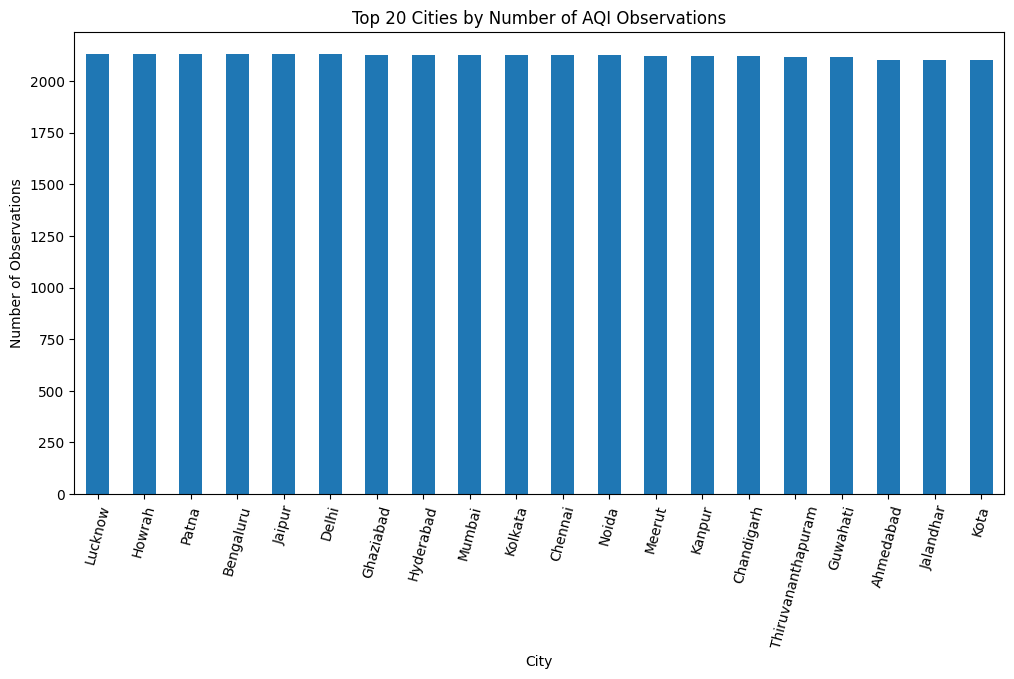

In [45]:
plt.figure(figsize=(12, 6))

city_counts.head(20).plot(kind="bar")

plt.title("Top 20 Cities by Number of AQI Observations")
plt.xlabel("City")
plt.ylabel("Number of Observations")
plt.xticks(rotation=75)
plt.show()

Question 2: Which cities have the highest average AQI?

In [46]:
city_avg_aqi = (
    df.groupby("City")["AQI Value"]
    .mean()
    .sort_values(ascending=False)
)

display(city_avg_aqi.head(20))

,AQI Value
City,
Greater_Noida,276.859649
Byrnihat,226.371011
Darbhanga,207.712531
Delhi,198.412870
Greater Noida,195.468538
Ghaziabad,192.139568
Faridabad,190.199485
Bhiwadi,185.698405
Noida,185.448519


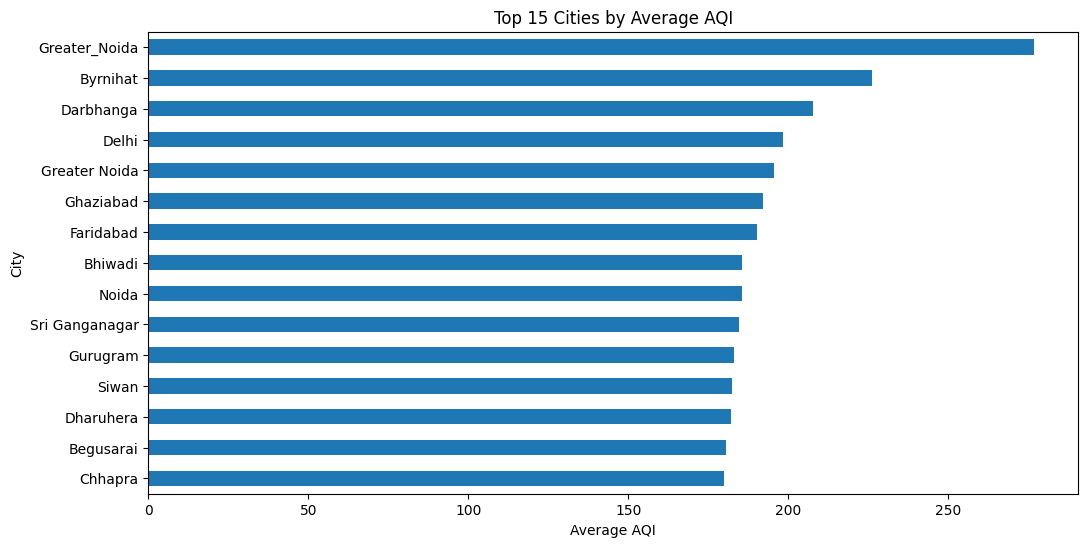

In [47]:
plt.figure(figsize=(12, 6))

city_avg_aqi.head(15).sort_values().plot(kind="barh")

plt.title("Top 15 Cities by Average AQI")
plt.xlabel("Average AQI")
plt.ylabel("City")
plt.show()

Among the cities represented in this dataset, Greater Noida had the highest average recorded AQI during the study period

In [48]:
# AQI Category Analysis
df["Air Quality"].value_counts()

,count
Air Quality,
Satisfactory,143820
Moderate,114209
Good,74986
Poor,33894
Very Poor,10243
Severe,1176


In [49]:
aqi_category_percentage = (
    df["Air Quality"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(aqi_category_percentage)

,proportion
Air Quality,
Satisfactory,38.01
Moderate,30.19
Good,19.82
Poor,8.96
Very Poor,2.71
Severe,0.31


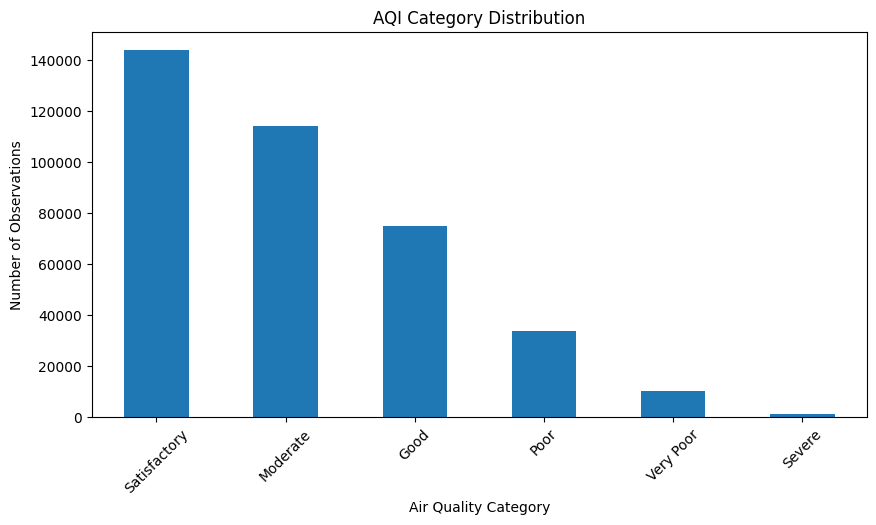

In [50]:
plt.figure(figsize=(10, 5))

df["Air Quality"].value_counts().plot(kind="bar")

plt.title("AQI Category Distribution")
plt.xlabel("Air Quality Category")
plt.ylabel("Number of Observations")
plt.xticks(rotation=45)
plt.show()

In [51]:
# Yearly AQI Trend
df["Year"] = df["Date"].dt.year

In [52]:
yearly_aqi = (
    df.groupby("Year")["AQI Value"]
    .mean()
)

display(yearly_aqi)

,AQI Value
Year,
2020,113.745539
2021,120.773451
2022,121.918020
2023,115.087274
2024,105.689502
2025,87.657520


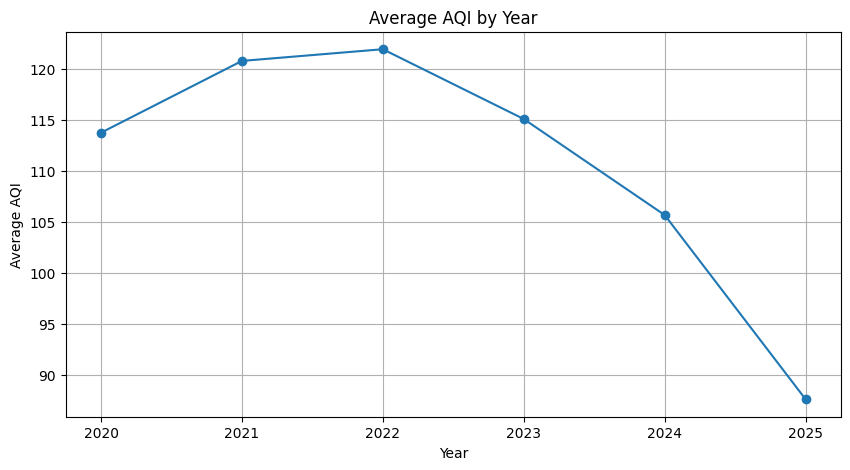

In [53]:
plt.figure(figsize=(10, 5))

yearly_aqi.plot(marker="o")

plt.title("Average AQI by Year")
plt.xlabel("Year")
plt.ylabel("Average AQI")
plt.grid(True)
plt.show()

In [54]:
df["Month_Number"] = df["Date"].dt.month

In [55]:
monthly_aqi = (
    df.groupby("Month_Number")["AQI Value"]
    .mean()
)

display(monthly_aqi)

,AQI Value
Month_Number,
1,155.610771
2,132.573217
3,117.193830
4,112.552740
5,99.827642
6,86.286533
7,62.113009
8,62.600812
9,66.076666


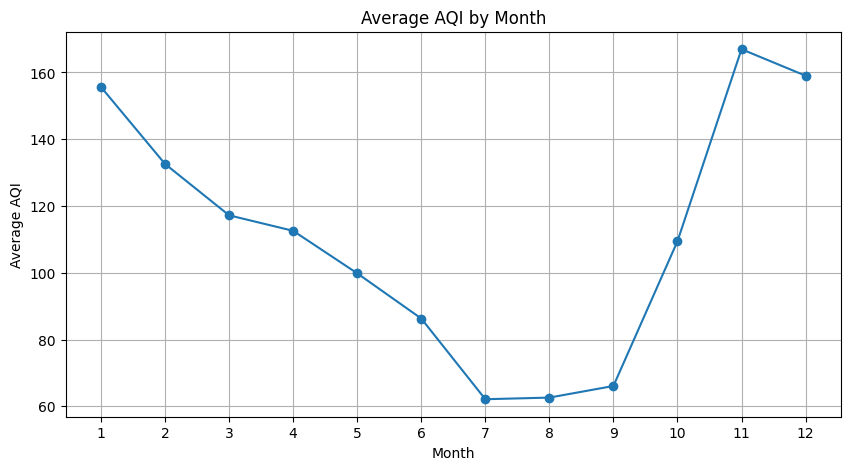

In [56]:
plt.figure(figsize=(10, 5))

monthly_aqi.plot(marker="o")

plt.title("Average AQI by Month")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

In [57]:
# Monthly AQI by Year
monthly_yearly_aqi = (
    df.groupby(["Year", "Month_Number"])["AQI Value"]
    .mean()
    .unstack()
)

display(monthly_yearly_aqi)

Month_Number,1,2,3,4,5,6,7,8,9,10,11,12
Year,,,,,,,,,,,,
2020,156.887225,144.506260,98.237882,84.551351,93.406663,76.976125,60.581053,52.590652,77.826391,147.312571,179.047233,179.746023
2021,172.702161,156.598701,142.075266,126.103557,91.069811,85.635469,68.714954,67.394750,57.303872,108.862897,184.517036,178.763957
2022,154.593407,137.708029,144.191787,140.681279,122.354040,106.250000,61.290134,64.694450,70.024571,111.067442,164.375313,173.903564
2023,171.742263,144.538650,114.564054,114.111402,102.753174,88.495558,64.668041,76.935489,70.909803,114.161864,167.330000,152.813662
2024,157.626969,120.884188,108.912688,111.173055,108.415647,89.758008,62.150704,55.236735,63.148712,98.658854,153.137064,131.505895
2025,131.369655,112.870330,105.540028,99.392974,80.514175,71.882642,56.914805,56.929243,61.106013,97.530157,NaN,NaN


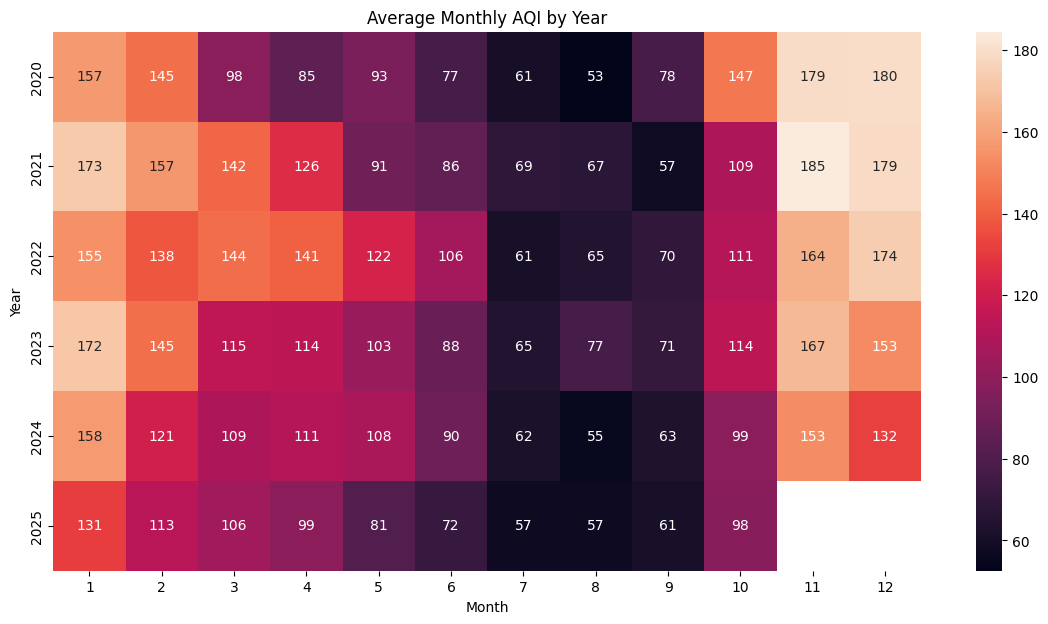

In [59]:
plt.figure(figsize=(14, 7))

sns.heatmap(
    monthly_yearly_aqi,
    annot=True,
    fmt=".0f"
)

plt.title("Average Monthly AQI by Year")
plt.xlabel("Month")
plt.ylabel("Year")
plt.show()

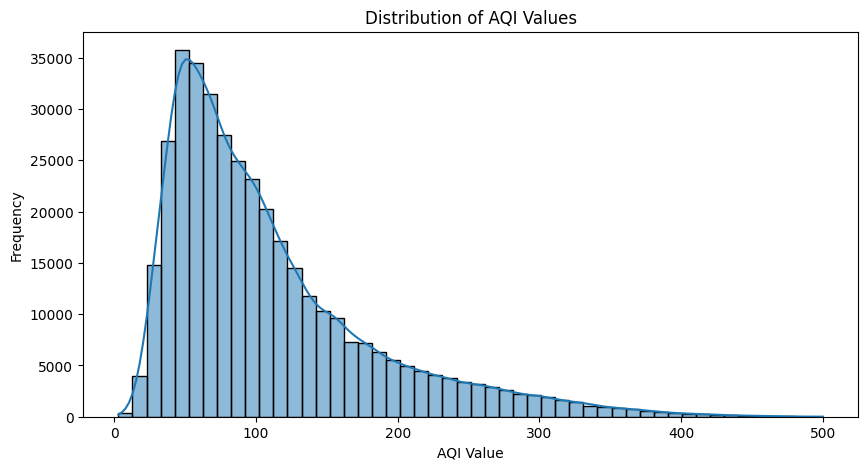

In [60]:
# AQI Distribution

plt.figure(figsize=(10, 5))

sns.histplot(
    df["AQI Value"],
    bins=50,
    kde=True
)

plt.title("Distribution of AQI Values")
plt.xlabel("AQI Value")
plt.ylabel("Frequency")
plt.show()

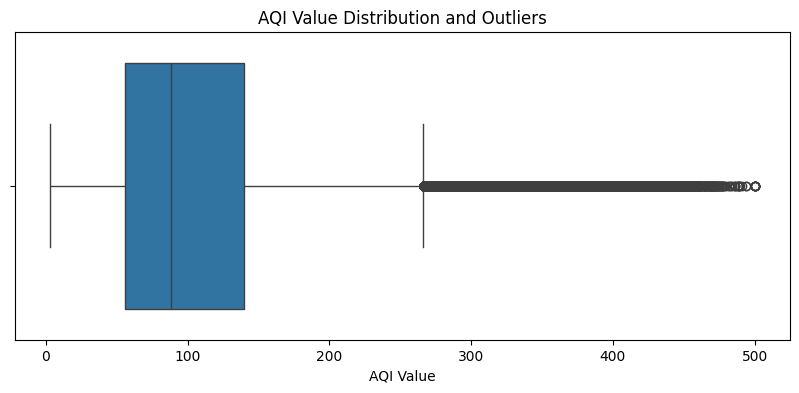

In [61]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=df["AQI Value"])

plt.title("AQI Value Distribution and Outliers")
plt.xlabel("AQI Value")
plt.show()

In [62]:
pollutant_counts = df["Prominent Pollutant"].value_counts()

display(pollutant_counts)

,count
Prominent Pollutant,
"PM 2.5, PM 10",378328


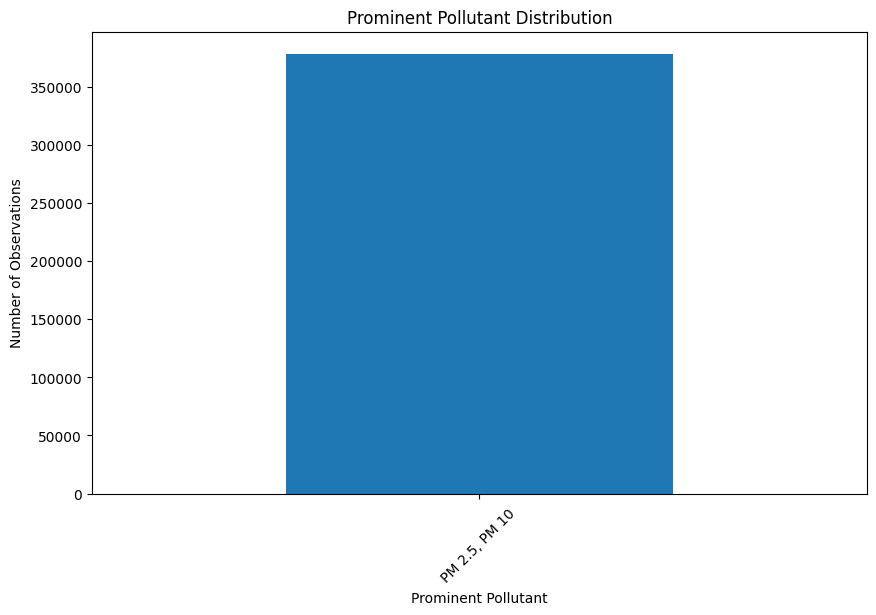

In [63]:
plt.figure(figsize=(10, 6))

pollutant_counts.plot(kind="bar")

plt.title("Prominent Pollutant Distribution")
plt.xlabel("Prominent Pollutant")
plt.ylabel("Number of Observations")
plt.xticks(rotation=45)
plt.show()

In [66]:
# AQI Category vs City
city_category = pd.crosstab(
    df["City"],
    df["Air Quality"]
)

display(city_category.head())

Air Quality,Good,Moderate,Poor,Satisfactory,Severe,Very Poor
City,,,,,,
Agartala,466,403,322,416,0,47
Agra,351,629,181,851,11,67
Ahmedabad,69,1073,94,864,0,2
Ahmednagar,126,166,38,193,0,0
Aizawl,1118,110,1,451,0,0


In [67]:
severe_cities = (
    city_category["Severe"]
    .sort_values(ascending=False)
    .head(15)
)

display(severe_cities)

,Severe
City,
Delhi,78
Begusarai,59
Greater Noida,57
Ghaziabad,54
Noida,51
Faridabad,50
Siwan,42
Bulandshahr,37
Purnia,33


In [68]:
df["Air Quality"].unique()

array(['Moderate', 'Very Poor', 'Severe', 'Poor', 'Satisfactory', 'Good'],
      dtype=object)

In [69]:
# 1. Cities with AQI >= 400
print(df[df["AQI Value"] >= 400].shape)

# 2. Which cities have the most AQI >= 400 days?
extreme_cities = (
    df[df["AQI Value"] >= 400]["City"]
    .value_counts()
    .head(15)
)

display(extreme_cities)

(1208, 7)


,count
City,
Delhi,81
Begusarai,60
Greater Noida,57
Ghaziabad,55
Faridabad,54
Noida,51
Siwan,44
Bulandshahr,37
Purnia,36


In [70]:
# 3. Check Noida naming
print([c for c in df["City"].unique() if "Noida" in c])

['Noida', 'Greater_Noida', 'Greater Noida']


In [71]:
# 4. Prominent pollutant distribution
display(df["Prominent Pollutant"].value_counts())

,count
Prominent Pollutant,
"PM 2.5, PM 10",378328


Extreme AQI observations (≥400) are relatively uncommon in the overall dataset, but they are concentrated more heavily in certain cities, with Delhi recording the highest number of such observations.

In [72]:
df["City"] = df["City"].replace({
    "Greater_Noida": "Greater Noida"
})

In [73]:
[c for c in df["City"].unique() if "Noida" in c]

['Noida', 'Greater Noida']

In [74]:
df["City"].value_counts().head(20)

,count
City,
Lucknow,2130
Howrah,2130
Bengaluru,2129
Patna,2129
Delhi,2129
Jaipur,2129
Mumbai,2128
Ghaziabad,2128
Kolkata,2128


In [75]:
city_avg_aqi = (
    df.groupby("City")["AQI Value"]
    .mean()
    .sort_values(ascending=False)
)

display(city_avg_aqi.head(15))

,AQI Value
City,
Byrnihat,226.371011
Darbhanga,207.712531
Delhi,198.412870
Greater Noida,197.653792
Ghaziabad,192.139568
Faridabad,190.199485
Bhiwadi,185.698405
Noida,185.448519
Sri Ganganagar,184.744633


In [76]:
df = df.drop(columns=["Prominent Pollutant"])

In [77]:
df.shape

(378328, 6)

In [78]:
df.columns

Index(['Date', 'City', 'Air Quality', 'AQI Value', 'Year', 'Month_Number'], dtype='object')

In [79]:
cities_to_check = [
    "Delhi",
    "Mumbai",
    "Kolkata",
    "Bengaluru",
    "Chennai"
]

for city in cities_to_check:
    city_data = df[df["City"] == city]

    print(
        city,
        "| Records:", len(city_data),
        "| Start:", city_data["Date"].min(),
        "| End:", city_data["Date"].max()
    )

Delhi | Records: 2129 | Start: 2020-01-01 00:00:00 | End: 2025-10-31 00:00:00
Mumbai | Records: 2128 | Start: 2020-01-01 00:00:00 | End: 2025-10-31 00:00:00
Kolkata | Records: 2128 | Start: 2020-01-01 00:00:00 | End: 2025-10-31 00:00:00
Bengaluru | Records: 2129 | Start: 2020-01-01 00:00:00 | End: 2025-10-31 00:00:00
Chennai | Records: 2127 | Start: 2020-01-01 00:00:00 | End: 2025-10-31 00:00:00


In [80]:
delhi = df[df["City"] == "Delhi"].copy()

delhi = delhi.sort_values("Date")

print(delhi.shape)
display(delhi.head())

(2129, 6)


,Date,City,Air Quality,AQI Value,Year,Month_Number
73,2020-01-01,Delhi,Severe,437,2020,1
171,2020-01-02,Delhi,Severe,417,2020,1
272,2020-01-03,Delhi,Very Poor,352,2020,1
366,2020-01-04,Delhi,Very Poor,334,2020,1
465,2020-01-05,Delhi,Very Poor,330,2020,1


In [81]:
print("Duplicate dates:", delhi["Date"].duplicated().sum())

Duplicate dates: 0


In [82]:
date_range = pd.date_range(
    start=delhi["Date"].min(),
    end=delhi["Date"].max(),
    freq="D"
)

print("Expected days:", len(date_range))
print("Actual records:", len(delhi))

Expected days: 2131
Actual records: 2129


In [83]:
missing_dates = date_range.difference(delhi["Date"])

print("Missing dates:", len(missing_dates))

Missing dates: 2


In [84]:
print(missing_dates[:20])

DatetimeIndex(['2023-07-17', '2025-01-01'], dtype='datetime64[ns]', freq=None)


In [85]:
delhi_ts = delhi[["Date", "AQI Value"]].copy()

delhi_ts = delhi_ts.set_index("Date")

delhi_ts.head()

,AQI Value
Date,
2020-01-01,437
2020-01-02,417
2020-01-03,352
2020-01-04,334
2020-01-05,330


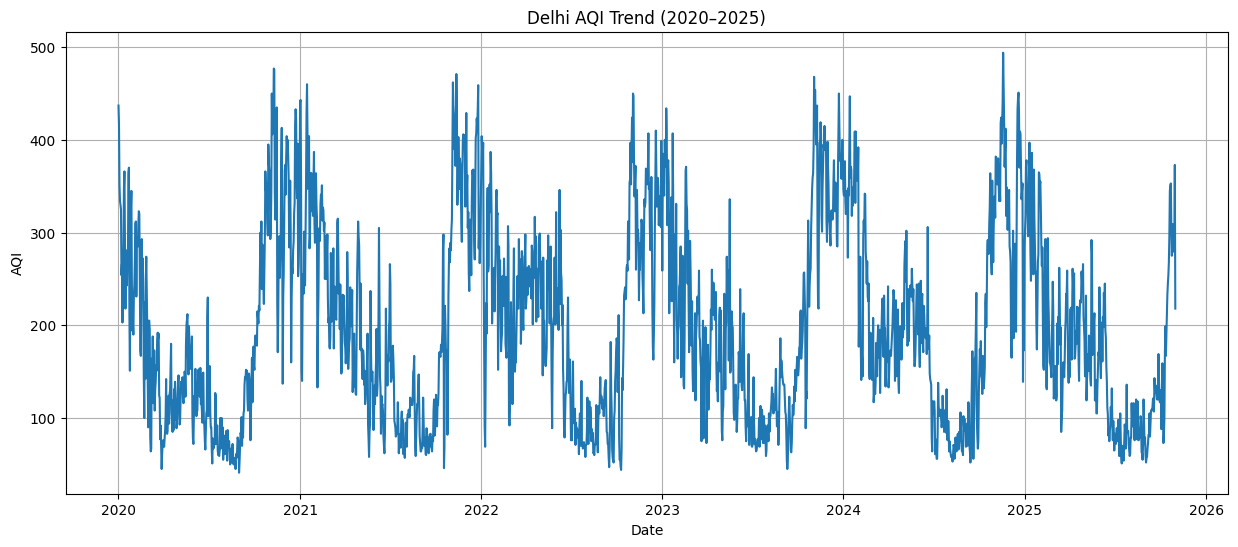

In [86]:
plt.figure(figsize=(15, 6))

plt.plot(
    delhi_ts.index,
    delhi_ts["AQI Value"]
)

plt.title("Delhi AQI Trend (2020–2025)")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.grid(True)

plt.show()

In [87]:
delhi_ts["Rolling_30"] = (
    delhi_ts["AQI Value"]
    .rolling(window=30)
    .mean()
)

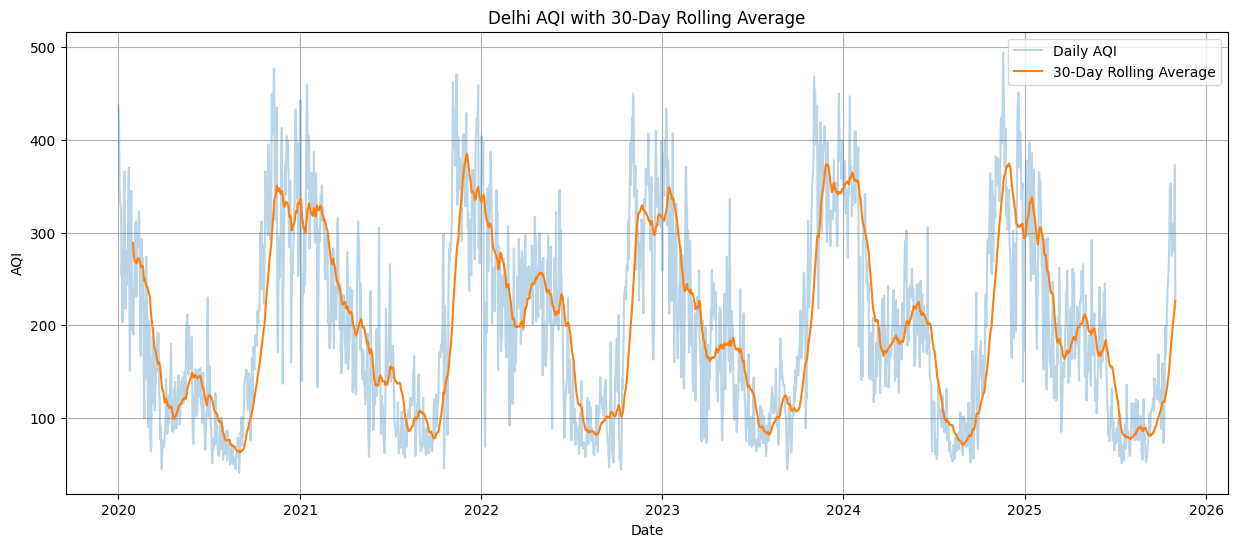

In [88]:
plt.figure(figsize=(15, 6))

plt.plot(
    delhi_ts.index,
    delhi_ts["AQI Value"],
    alpha=0.3,
    label="Daily AQI"
)

plt.plot(
    delhi_ts.index,
    delhi_ts["Rolling_30"],
    label="30-Day Rolling Average"
)

plt.title("Delhi AQI with 30-Day Rolling Average")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.legend()
plt.grid(True)

plt.show()

In [89]:
delhi_monthly = (
    delhi_ts["AQI Value"]
    .resample("ME")
    .mean()
)

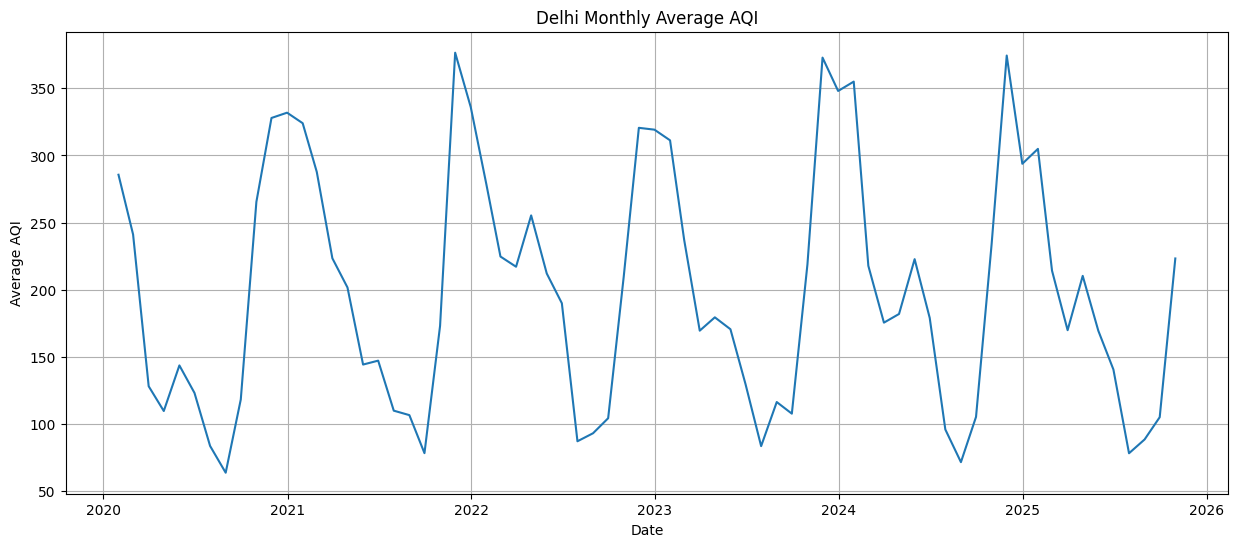

In [90]:
plt.figure(figsize=(15, 6))

plt.plot(delhi_monthly.index, delhi_monthly)

plt.title("Delhi Monthly Average AQI")
plt.xlabel("Date")
plt.ylabel("Average AQI")
plt.grid(True)

plt.show()

In [92]:
# Check seasonality
delhi_month = (
    delhi.reset_index(drop=True)
    .groupby("Month_Number")["AQI Value"]
    .mean()
)

display(delhi_month)

,AQI Value
Month_Number,
1,309.940541
2,237.123529
3,180.677419
4,189.822222
5,177.225806
6,151.688889
7,89.908108
8,90.123656
9,103.288889


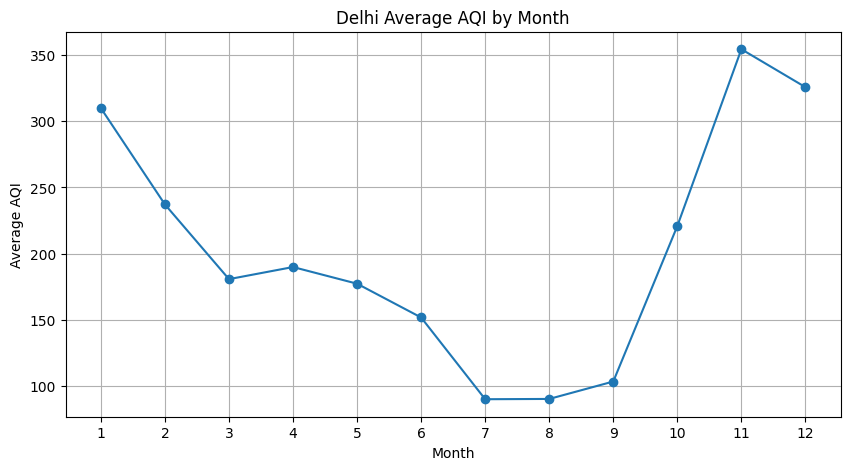

In [93]:
plt.figure(figsize=(10, 5))

plt.plot(
    delhi_month.index,
    delhi_month.values,
    marker="o"
)

plt.title("Delhi Average AQI by Month")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.xticks(range(1, 13))
plt.grid(True)

plt.show()

In [94]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(
    delhi_ts["AQI Value"].dropna()
)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -3.825678516313772
p-value: 0.0026552503819927934


/tmp/ipykernel_4214/3685624699.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(


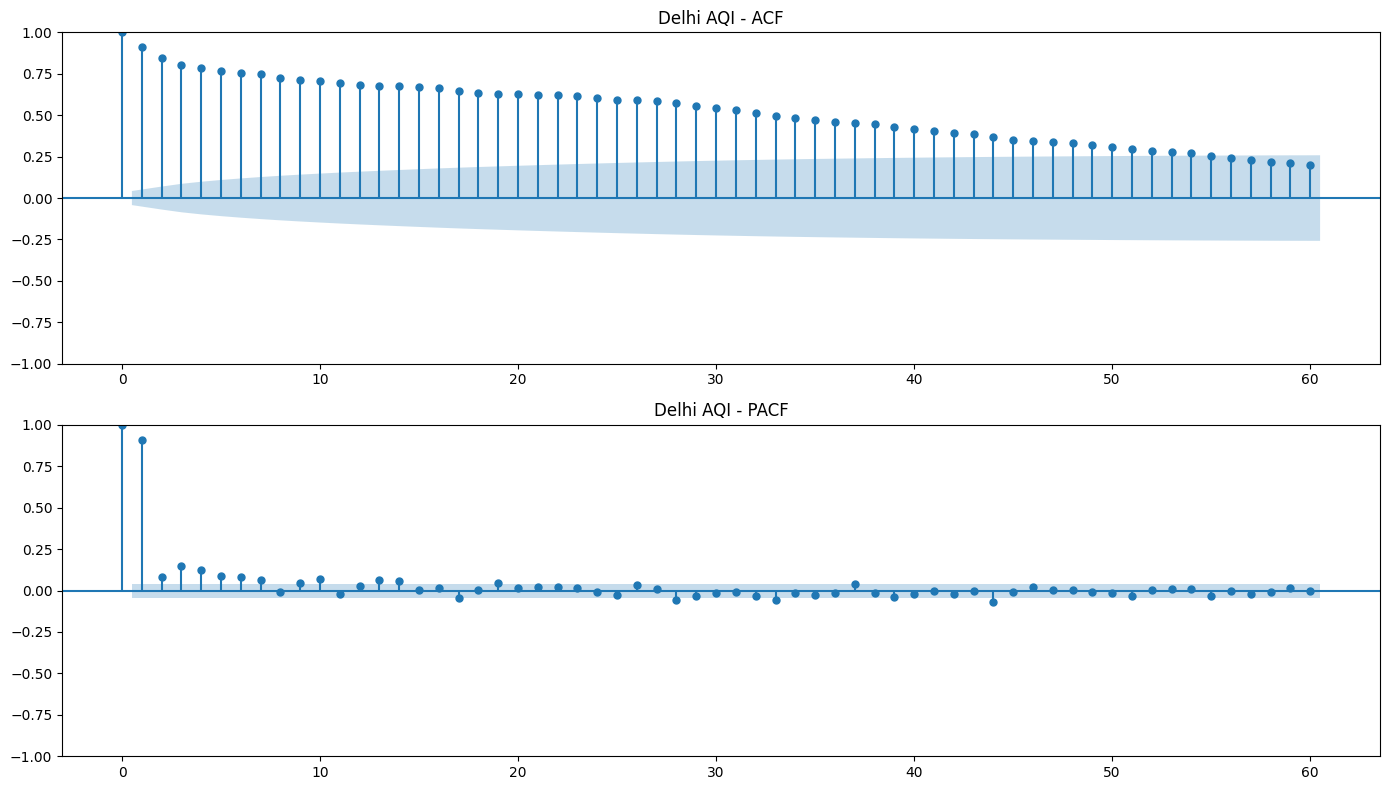

In [95]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(
    delhi["AQI Value"].dropna(),
    lags=60,
    ax=ax[0]
)

plot_pacf(
    delhi["AQI Value"].dropna(),
    lags=60,
    ax=ax[1],
    method="ywm"
)

ax[0].set_title("Delhi AQI - ACF")
ax[1].set_title("Delhi AQI - PACF")

plt.tight_layout()
plt.show()

In [96]:
date_range = pd.date_range(
    start=delhi["Date"].min(),
    end=delhi["Date"].max(),
    freq="D"
)

missing_dates = date_range.difference(delhi["Date"])

print("Expected days:", len(date_range))
print("Actual records:", len(delhi))
print("Missing dates:", len(missing_dates))

Expected days: 2131
Actual records: 2129
Missing dates: 2


In [97]:
print("Duplicate dates:", delhi["Date"].duplicated().sum())

Duplicate dates: 0


In [98]:
print(missing_dates)

DatetimeIndex(['2023-07-17', '2025-01-01'], dtype='datetime64[ns]', freq=None)


<Figure size 1500x600 with 0 Axes>

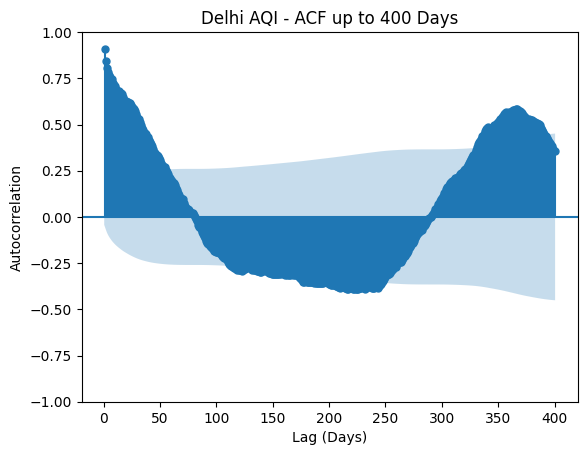

In [99]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(15, 6))

plot_acf(
    delhi["AQI Value"].dropna(),
    lags=400,
    zero=False
)

plt.title("Delhi AQI - ACF up to 400 Days")
plt.xlabel("Lag (Days)")
plt.ylabel("Autocorrelation")

plt.show()

In [101]:
delhi_ts = (
    delhi[["Date", "AQI Value"]]
    .set_index("Date")
    .sort_index()
)

# Create complete daily date range
full_dates = pd.date_range(
    start=delhi_ts.index.min(),
    end=delhi_ts.index.max(),
    freq="D"
)

# Reindex to include missing dates
delhi_ts = delhi_ts.reindex(full_dates)

# Name the index
delhi_ts.index.name = "Date"

print("Missing AQI before interpolation:",
      delhi_ts["AQI Value"].isna().sum())

Missing AQI before interpolation: 2


In [102]:
for date in missing_dates:
    print("\nMissing date:", date)
    print(
        delhi_ts.loc[
            date - pd.Timedelta(days=2):
            date + pd.Timedelta(days=2)
        ]
    )


Missing date: 2023-07-17 00:00:00
            AQI Value
Date                 
2023-07-15      100.0
2023-07-16       69.0
2023-07-17        NaN
2023-07-18      113.0
2023-07-19       77.0

Missing date: 2025-01-01 00:00:00
            AQI Value
Date                 
2024-12-30      173.0
2024-12-31      283.0
2025-01-01        NaN
2025-01-02      318.0
2025-01-03      371.0


In [103]:
delhi_ts["AQI Value"] = (
    delhi_ts["AQI Value"]
    .interpolate(method="time")
)

In [104]:
print(
    "Missing AQI after interpolation:",
    delhi_ts["AQI Value"].isna().sum()
)

Missing AQI after interpolation: 0


In [105]:
print("Rows:", len(delhi_ts))
print("Start:", delhi_ts.index.min())
print("End:", delhi_ts.index.max())

print(
    "Missing values:",
    delhi_ts["AQI Value"].isna().sum()
)

Rows: 2131
Start: 2020-01-01 00:00:00
End: 2025-10-31 00:00:00
Missing values: 0


Two missing daily observations were identified in the Delhi time series (17 July 2023 and 1 January 2025). The missing values were handled using time-based interpolation to maintain a continuous daily time series for forecasting.

In [106]:
# Define test period
test_days = 30

train = delhi_ts.iloc[:-test_days].copy()
test = delhi_ts.iloc[-test_days:].copy()

print("Training records:", len(train))
print("Testing records:", len(test))

print("\nTraining period:")
print(train.index.min(), "to", train.index.max())

print("\nTesting period:")
print(test.index.min(), "to", test.index.max())

Training records: 2101
Testing records: 30

Training period:
2020-01-01 00:00:00 to 2025-10-01 00:00:00

Testing period:
2025-10-02 00:00:00 to 2025-10-31 00:00:00


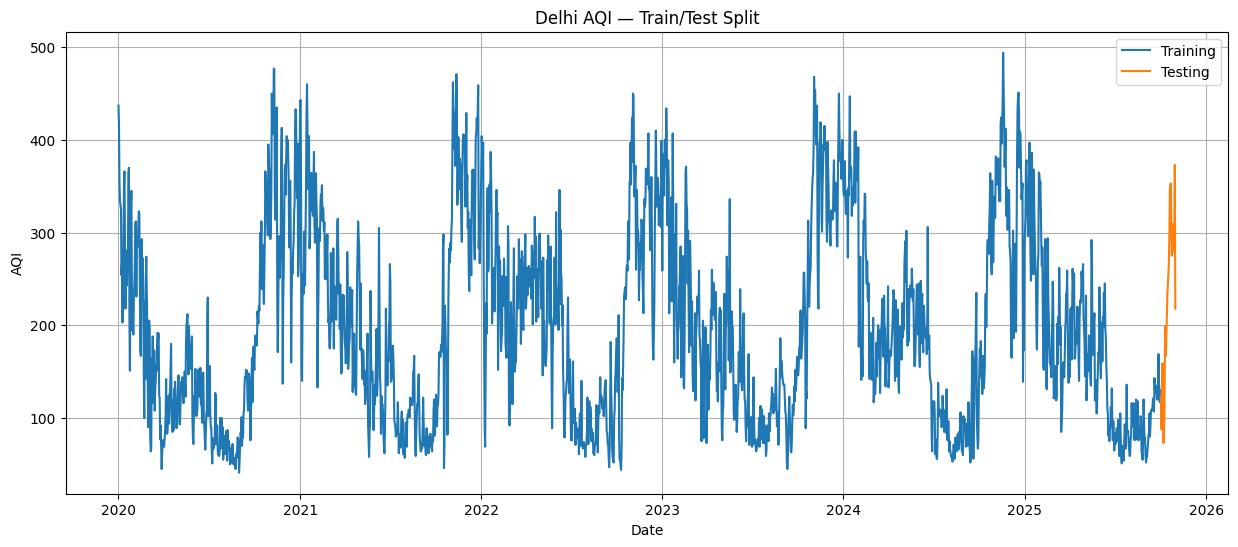

In [107]:
plt.figure(figsize=(15, 6))

plt.plot(
    train.index,
    train["AQI Value"],
    label="Training"
)

plt.plot(
    test.index,
    test["AQI Value"],
    label="Testing"
)

plt.title("Delhi AQI — Train/Test Split")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.legend()
plt.grid(True)

plt.show()

In [108]:
# Naive forecast
naive_predictions = test["AQI Value"].shift(1)

# First test prediction needs the last training value
naive_predictions.iloc[0] = train["AQI Value"].iloc[-1]

naive_predictions.head()

,AQI Value
Date,
2025-10-02,130.0
2025-10-03,123.0
2025-10-04,88.0
2025-10-05,138.0
2025-10-06,159.0


In [109]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(
    test["AQI Value"],
    naive_predictions
)

rmse = np.sqrt(
    mean_squared_error(
        test["AQI Value"],
        naive_predictions
    )
)

mape = np.mean(
    np.abs(
        (test["AQI Value"] - naive_predictions)
        / test["AQI Value"]
    )
) * 100

print("Naive Baseline")
print("----------------")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("MAPE:", round(mape, 2), "%")

Naive Baseline
----------------
MAE : 31.13
RMSE: 43.75
MAPE: 16.99 %


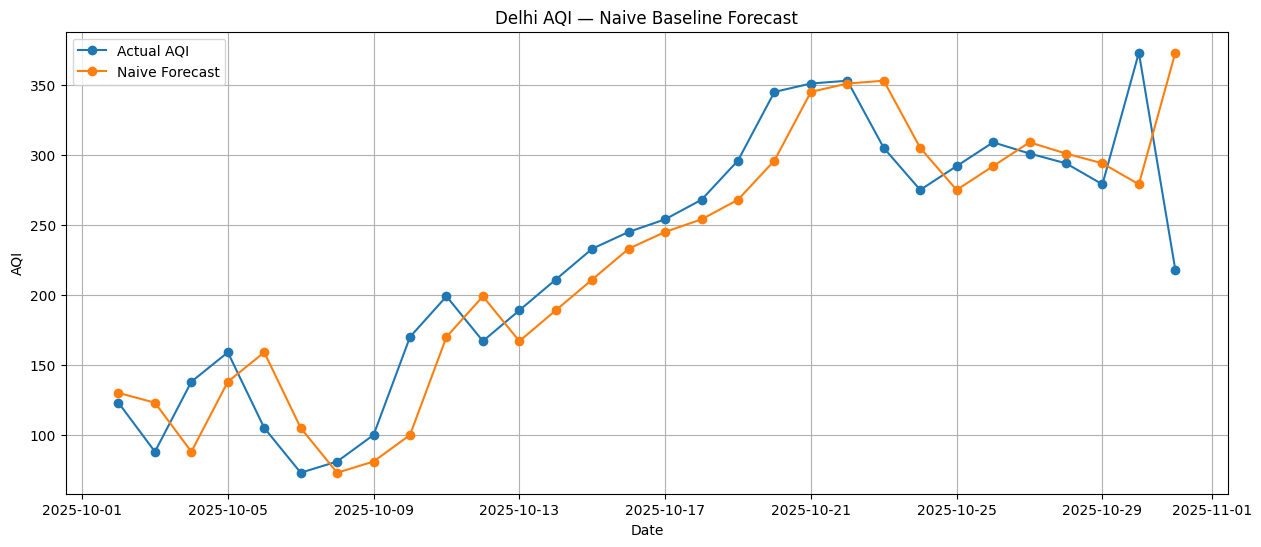

In [110]:
plt.figure(figsize=(15, 6))

plt.plot(
    test.index,
    test["AQI Value"],
    marker="o",
    label="Actual AQI"
)

plt.plot(
    test.index,
    naive_predictions,
    marker="o",
    label="Naive Forecast"
)

plt.title("Delhi AQI — Naive Baseline Forecast")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.legend()
plt.grid(True)

plt.show()

In [111]:
from statsmodels.tsa.arima.model import ARIMA

In [112]:
arima_model = ARIMA(
    train["AQI Value"],
    order=(1, 0, 0)
)

arima_result = arima_model.fit()

print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:              AQI Value   No. Observations:                 2101
Model:                 ARIMA(1, 0, 0)   Log Likelihood              -10849.042
Date:                Sun, 20 Sep 2026   AIC                          21704.085
Time:                        02:56:55   BIC                          21721.035
Sample:                    01-01-2020   HQIC                         21710.293
                         - 10-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        198.0162     11.829     16.740      0.000     174.832     221.200
ar.L1          0.9129      0.010     87.253      0.000       0.892       0.933
sigma2      1787.8804     40.861     43.755      0.0

In [113]:
arima_forecast = arima_result.forecast(
    steps=len(test)
)

arima_forecast.index = test.index

In [114]:
arima_mae = mean_absolute_error(
    test["AQI Value"],
    arima_forecast
)

arima_rmse = np.sqrt(
    mean_squared_error(
        test["AQI Value"],
        arima_forecast
    )
)

arima_mape = np.mean(
    np.abs(
        (test["AQI Value"] - arima_forecast)
        / test["AQI Value"]
    )
) * 100

print("ARIMA(1,0,0)")
print("----------------")
print("MAE :", round(arima_mae, 2))
print("RMSE:", round(arima_rmse, 2))
print("MAPE:", round(arima_mape, 2), "%")


ARIMA(1,0,0)
----------------
MAE : 74.83
RMSE: 90.33
MAPE: 34.81 %


In [115]:
comparison = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "ARIMA(1,0,0)"
    ],
    "MAE": [
        mae,
        arima_mae
    ],
    "RMSE": [
        rmse,
        arima_rmse
    ],
    "MAPE (%)": [
        mape,
        arima_mape
    ]
})

comparison

,Model,MAE,RMSE,MAPE (%)
0,Naive Baseline,31.133333,43.750810,16.991822
1,"ARIMA(1,0,0)",74.833720,90.334002,34.813680


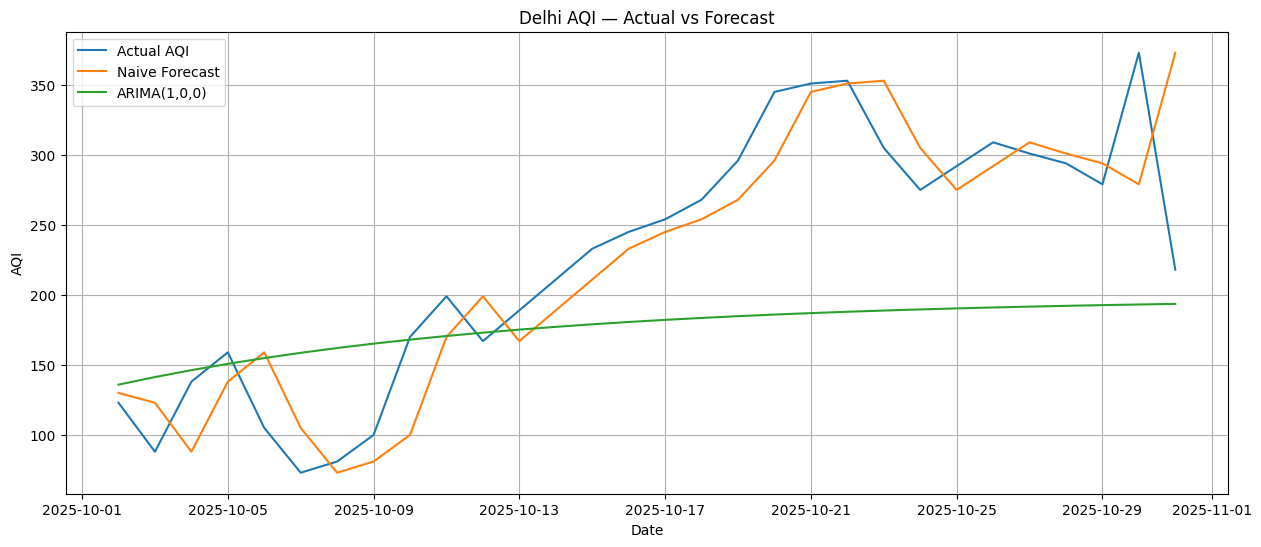

In [116]:
plt.figure(figsize=(15, 6))

plt.plot(
    test.index,
    test["AQI Value"],
    label="Actual AQI"
)

plt.plot(
    test.index,
    naive_predictions,
    label="Naive Forecast"
)

plt.plot(
    test.index,
    arima_forecast,
    label="ARIMA(1,0,0)"
)

plt.title("Delhi AQI — Actual vs Forecast")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.legend()
plt.grid(True)

plt.show()

In [117]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train["AQI Value"],
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit(disp=False)

print(sarima_result.summary())

                                     SARIMAX Results                                     
Dep. Variable:                         AQI Value   No. Observations:                 2101
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 7)   Log Likelihood              -10807.812
Date:                           Sun, 20 Sep 2026   AIC                          21625.623
Time:                                   03:00:20   BIC                          21653.853
Sample:                               01-01-2020   HQIC                         21635.965
                                    - 10-01-2025                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9810      0.004    236.514      0.000       0.973       0.989
ma.L1         -0.1911      0.019    -10.294

In [118]:
sarima_forecast = sarima_result.forecast(
    steps=len(test)
)

sarima_forecast.index = test.index

In [119]:
sarima_mae = mean_absolute_error(
    test["AQI Value"],
    sarima_forecast
)

sarima_rmse = np.sqrt(
    mean_squared_error(
        test["AQI Value"],
        sarima_forecast
    )
)

sarima_mape = np.mean(
    np.abs(
        (test["AQI Value"] - sarima_forecast)
        / test["AQI Value"]
    )
) * 100

print("SARIMA(1,0,1)(1,0,1,7)")
print("-------------------------")
print("MAE :", round(sarima_mae, 2))
print("RMSE:", round(sarima_rmse, 2))
print("MAPE:", round(sarima_mape, 2), "%")

SARIMA(1,0,1)(1,0,1,7)
-------------------------
MAE : 132.94
RMSE: 158.55
MAPE: 51.94 %


In [120]:
comparison = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "ARIMA(1,0,0)",
        "SARIMA(1,0,1)(1,0,1,7)"
    ],
    "MAE": [
        mae,
        arima_mae,
        sarima_mae
    ],
    "RMSE": [
        rmse,
        arima_rmse,
        sarima_rmse
    ],
    "MAPE (%)": [
        mape,
        arima_mape,
        sarima_mape
    ]
})

comparison

,Model,MAE,RMSE,MAPE (%)
0,Naive Baseline,31.133333,43.750810,16.991822
1,"ARIMA(1,0,0)",74.833720,90.334002,34.813680
2,"SARIMA(1,0,1)(1,0,1,7)",132.939502,158.550505,51.944458


In [121]:
naive_30_forecast = pd.Series(
    train["AQI Value"].iloc[-1],
    index=test.index
)

naive_30_mae = mean_absolute_error(
    test["AQI Value"],
    naive_30_forecast
)

naive_30_rmse = np.sqrt(
    mean_squared_error(
        test["AQI Value"],
        naive_30_forecast
    )
)

naive_30_mape = np.mean(
    np.abs(
        (test["AQI Value"] - naive_30_forecast)
        / test["AQI Value"]
    )
) * 100

print("Naive 30-Day Forecast")
print("----------------------")
print("MAE :", round(naive_30_mae, 2))
print("RMSE:", round(naive_30_rmse, 2))
print("MAPE:", round(naive_30_mape, 2), "%")

Naive 30-Day Forecast
----------------------
MAE : 110.47
RMSE: 130.81
MAPE: 45.03 %


Now that we're comparing 30-day-ahead forecasts, ARIMA is actually better than the constant naive baseline:

MAE: 110.47 → 74.83
RMSE: 130.81 → 90.33
MAPE: 45.03% → 34.81%

So ARIMA(1,0,0) is currently our better-performing tested model.

In [122]:
from statsmodels.tsa.arima.model import ARIMA

orders = [
    (1, 0, 0),
    (2, 0, 0),
    (1, 0, 1),
    (2, 0, 1),
    (2, 0, 2)
]

arima_results = []

for order in orders:
    try:
        model = ARIMA(
            train["AQI Value"],
            order=order
        )

        result = model.fit()

        forecast = result.forecast(steps=len(test))
        forecast.index = test.index

        mae_score = mean_absolute_error(
            test["AQI Value"],
            forecast
        )

        rmse_score = np.sqrt(
            mean_squared_error(
                test["AQI Value"],
                forecast
            )
        )

        mape_score = np.mean(
            np.abs(
                (test["AQI Value"] - forecast)
                / test["AQI Value"]
            )
        ) * 100

        arima_results.append({
            "Model": f"ARIMA{order}",
            "MAE": mae_score,
            "RMSE": rmse_score,
            "MAPE (%)": mape_score
        })

    except Exception as e:
        print(f"ARIMA{order} failed:", e)

arima_comparison = pd.DataFrame(arima_results)

arima_comparison.sort_values("MAE")

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


,Model,MAE,RMSE,MAPE (%)
0,"ARIMA(1, 0, 0)",74.833720,90.334002,34.813680
1,"ARIMA(2, 0, 0)",76.685000,92.412859,35.007540
2,"ARIMA(1, 0, 1)",78.496154,94.349806,35.362240
4,"ARIMA(2, 0, 2)",100.097987,118.454210,41.839822
3,"ARIMA(2, 0, 1)",101.181253,119.749439,42.089025


For this Delhi 30-day test period, ARIMA(1,0,0) has the lowest MAE, RMSE, and MAPE among the tested ARIMA configurations.

So keep it as your current best daily ARIMA model.

In [123]:
delhi_monthly = (
    delhi
    .set_index("Date")["AQI Value"]
    .resample("ME")
    .mean()
)

print("Number of monthly observations:", len(delhi_monthly))

display(delhi_monthly.head(15))

Number of monthly observations: 70


,AQI Value
Date,
2020-01-31,285.677419
2020-02-29,241.206897
2020-03-31,128.225806
2020-04-30,109.800000
2020-05-31,143.741935
2020-06-30,123.266667
2020-07-31,83.806452
2020-08-31,63.870968
2020-09-30,118.400000


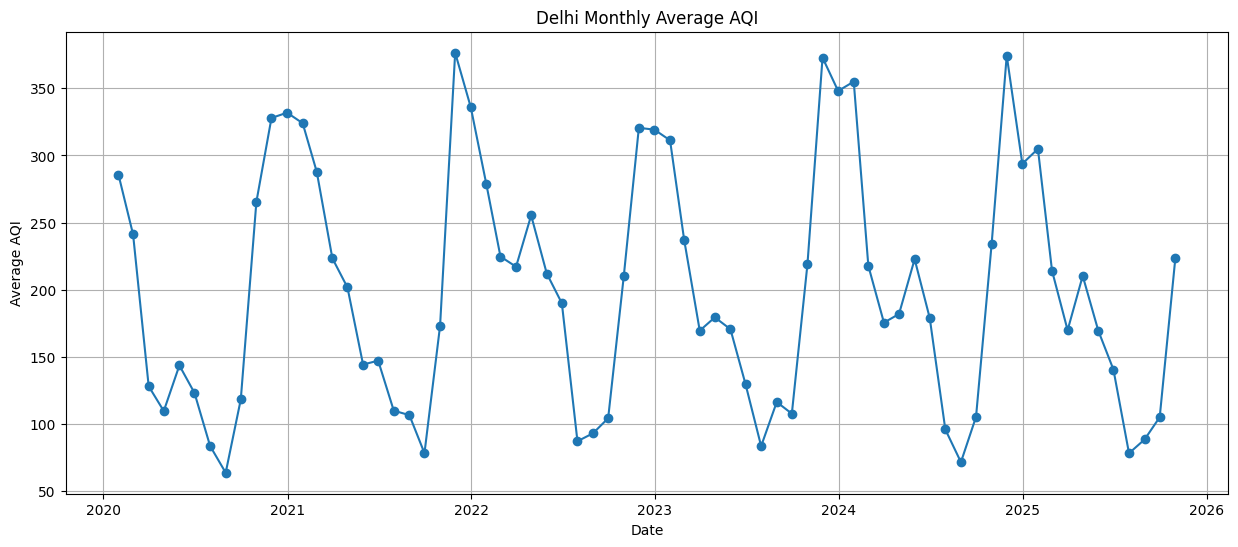

In [124]:
plt.figure(figsize=(15, 6))

plt.plot(
    delhi_monthly.index,
    delhi_monthly.values,
    marker="o"
)

plt.title("Delhi Monthly Average AQI")
plt.xlabel("Date")
plt.ylabel("Average AQI")
plt.grid(True)

plt.show()

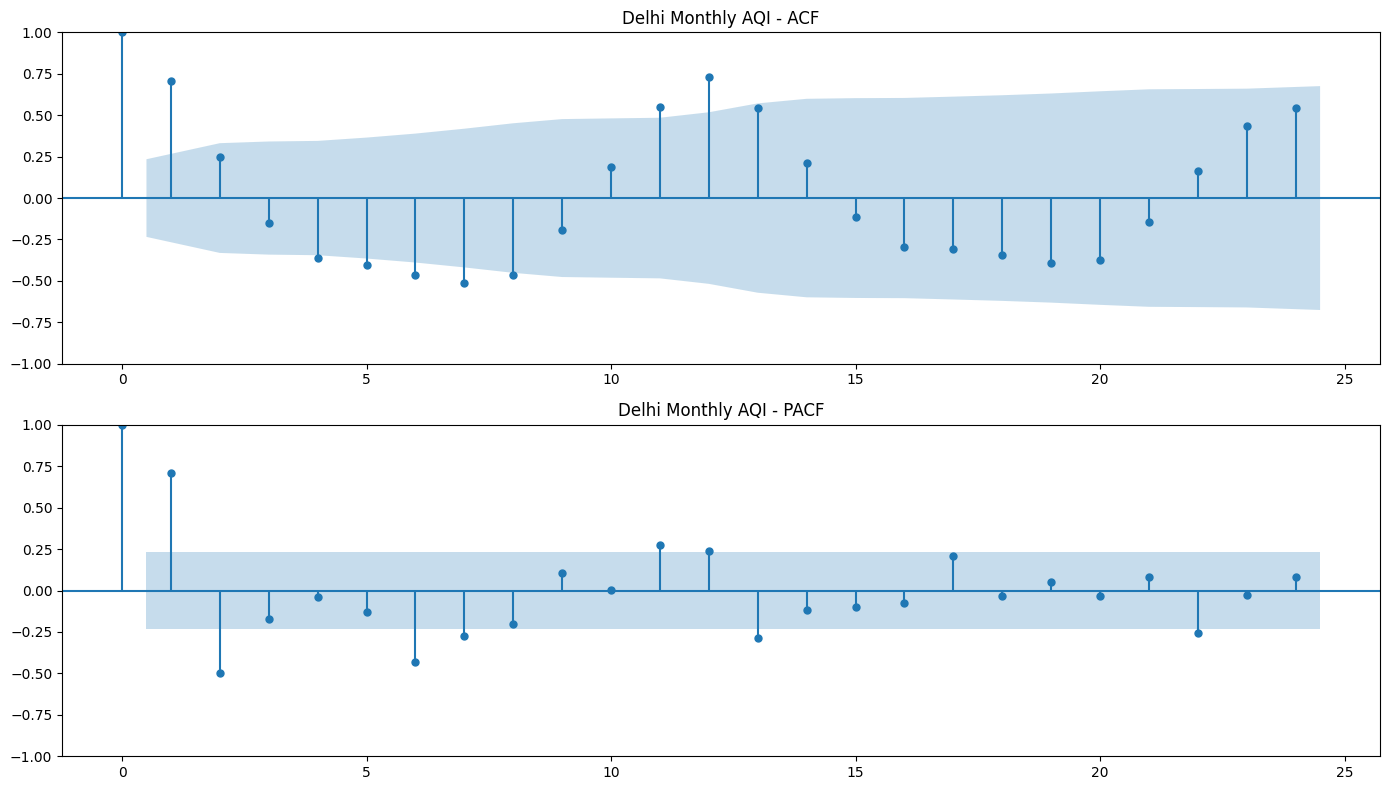

In [125]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(
    delhi_monthly,
    lags=24,
    ax=ax[0]
)

plot_pacf(
    delhi_monthly,
    lags=24,
    ax=ax[1],
    method="ywm"
)

ax[0].set_title("Delhi Monthly AQI - ACF")
ax[1].set_title("Delhi Monthly AQI - PACF")

plt.tight_layout()
plt.show()

In [126]:
monthly_train = delhi_monthly.iloc[:-12].copy()
monthly_test = delhi_monthly.iloc[-12:].copy()

print("Training observations:", len(monthly_train))
print("Testing observations:", len(monthly_test))

print("\nTraining period:")
print(monthly_train.index.min(), "to", monthly_train.index.max())

print("\nTesting period:")
print(monthly_test.index.min(), "to", monthly_test.index.max())

Training observations: 58
Testing observations: 12

Training period:
2020-01-31 00:00:00 to 2024-10-31 00:00:00

Testing period:
2024-11-30 00:00:00 to 2025-10-31 00:00:00


In [127]:
seasonal_naive = monthly_train.iloc[-12:].copy()

seasonal_naive.index = monthly_test.index

In [128]:
comparison_baseline = pd.DataFrame({
    "Actual": monthly_test,
    "Seasonal_Naive": seasonal_naive
})

display(comparison_baseline)

,Actual,Seasonal_Naive
Date,,
2024-11-30,374.400000,372.866667
2024-12-31,293.838710,348.032258
2025-01-31,304.933333,355.000000
2025-02-28,214.285714,217.896552
2025-03-31,169.967742,175.580645
2025-04-30,210.400000,182.033333
2025-05-31,169.548387,222.838710
2025-06-30,140.700000,179.066667
2025-07-31,78.354839,96.064516


In [129]:
monthly_naive_mae = mean_absolute_error(
    monthly_test,
    seasonal_naive
)

monthly_naive_rmse = np.sqrt(
    mean_squared_error(
        monthly_test,
        seasonal_naive
    )
)

monthly_naive_mape = np.mean(
    np.abs(
        (monthly_test - seasonal_naive)
        / monthly_test
    )
) * 100

print("Seasonal Naive Baseline")
print("-----------------------")
print("MAE :", round(monthly_naive_mae, 2))
print("RMSE:", round(monthly_naive_rmse, 2))
print("MAPE:", round(monthly_naive_mape, 2), "%")

Seasonal Naive Baseline
-----------------------
MAE : 23.38
RMSE: 30.72
MAPE: 13.26 %


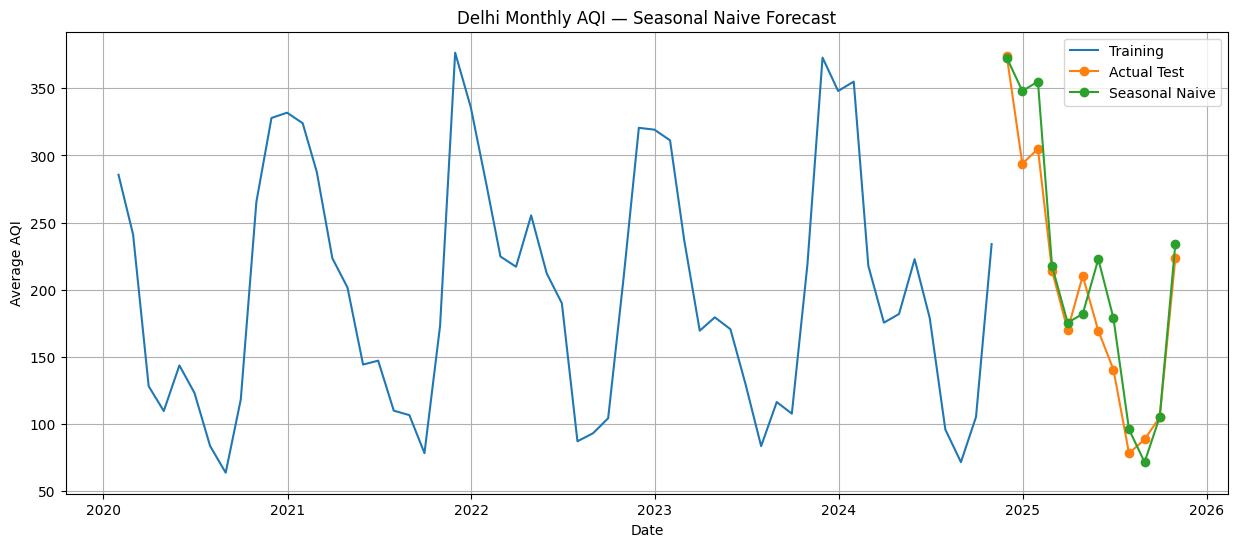

In [130]:
plt.figure(figsize=(15, 6))

plt.plot(
    monthly_train.index,
    monthly_train,
    label="Training"
)

plt.plot(
    monthly_test.index,
    monthly_test,
    marker="o",
    label="Actual Test"
)

plt.plot(
    monthly_test.index,
    seasonal_naive,
    marker="o",
    label="Seasonal Naive"
)

plt.title("Delhi Monthly AQI — Seasonal Naive Forecast")
plt.xlabel("Date")
plt.ylabel("Average AQI")
plt.legend()
plt.grid(True)

plt.show()

In [131]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_monthly = SARIMAX(
    monthly_train,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_monthly.fit(disp=False)

print(sarima_result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                          AQI Value   No. Observations:                   58
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood                -219.739
Date:                            Sun, 20 Sep 2026   AIC                            449.477
Time:                                    03:09:10   BIC                            458.398
Sample:                                01-31-2020   HQIC                           452.785
                                     - 10-31-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7955      0.103      7.737      0.000       0.594       0.997
ma.L1         -0.7904      0.143   

In [132]:
sarima_monthly_forecast = sarima_result.forecast(
    steps=len(monthly_test)
)

sarima_monthly_forecast.index = monthly_test.index

In [133]:
sarima_monthly_mae = mean_absolute_error(
    monthly_test,
    sarima_monthly_forecast
)

sarima_monthly_rmse = np.sqrt(
    mean_squared_error(
        monthly_test,
        sarima_monthly_forecast
    )
)

sarima_monthly_mape = np.mean(
    np.abs(
        (monthly_test - sarima_monthly_forecast)
        / monthly_test
    )
) * 100

print("Monthly SARIMA(1,0,1)(1,0,1,12)")
print("--------------------------------")
print("MAE :", round(sarima_monthly_mae, 2))
print("RMSE:", round(sarima_monthly_rmse, 2))
print("MAPE:", round(sarima_monthly_mape, 2), "%")

Monthly SARIMA(1,0,1)(1,0,1,12)
--------------------------------
MAE : 16.55
RMSE: 19.96
MAPE: 8.68 %


In [134]:
monthly_comparison = pd.DataFrame({
    "Model": [
        "Seasonal Naive",
        "SARIMA(1,0,1)(1,0,1,12)"
    ],
    "MAE": [
        monthly_naive_mae,
        sarima_monthly_mae
    ],
    "RMSE": [
        monthly_naive_rmse,
        sarima_monthly_rmse
    ],
    "MAPE (%)": [
        monthly_naive_mape,
        sarima_monthly_mape
    ]
})

display(monthly_comparison)

,Model,MAE,RMSE,MAPE (%)
0,Seasonal Naive,23.383072,30.715274,13.260631
1,"SARIMA(1,0,1)(1,0,1,12)",16.548937,19.960023,8.675052


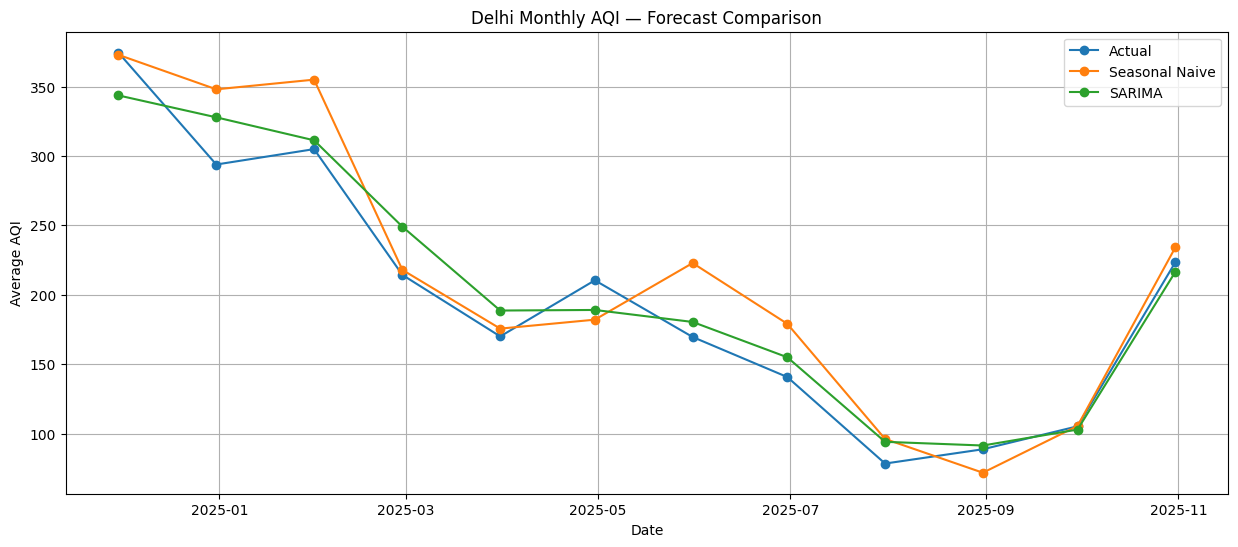

In [135]:
plt.figure(figsize=(15, 6))

plt.plot(
    monthly_test.index,
    monthly_test,
    marker="o",
    label="Actual"
)

plt.plot(
    monthly_test.index,
    seasonal_naive,
    marker="o",
    label="Seasonal Naive"
)

plt.plot(
    monthly_test.index,
    sarima_monthly_forecast,
    marker="o",
    label="SARIMA"
)

plt.title("Delhi Monthly AQI — Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Average AQI")
plt.legend()
plt.grid(True)

plt.show()

In [136]:
# Build the actual 6–12 month forecast
final_sarima = SARIMAX(
    delhi_monthly,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_sarima_result = final_sarima.fit(disp=False)

In [137]:
future_forecast = final_sarima_result.forecast(
    steps=12
)

print(future_forecast)

2025-11-30    360.964282
2025-12-31    332.060036
2026-01-31    321.079458
2026-02-28    239.052551
2026-03-31    184.331812
2026-04-30    194.340104
2026-05-31    181.496822
2026-06-30    155.268656
2026-07-31     91.912789
2026-08-31     92.233516
2026-09-30    105.687340
2026-10-31    225.935916
Freq: ME, Name: predicted_mean, dtype: float64


In [138]:
forecast_table = pd.DataFrame({
    "Date": future_forecast.index,
    "Forecasted_AQI": future_forecast.values
})

display(forecast_table)

,Date,Forecasted_AQI
0,2025-11-30,360.964282
1,2025-12-31,332.060036
2,2026-01-31,321.079458
3,2026-02-28,239.052551
4,2026-03-31,184.331812
5,2026-04-30,194.340104
6,2026-05-31,181.496822
7,2026-06-30,155.268656
8,2026-07-31,91.912789
9,2026-08-31,92.233516


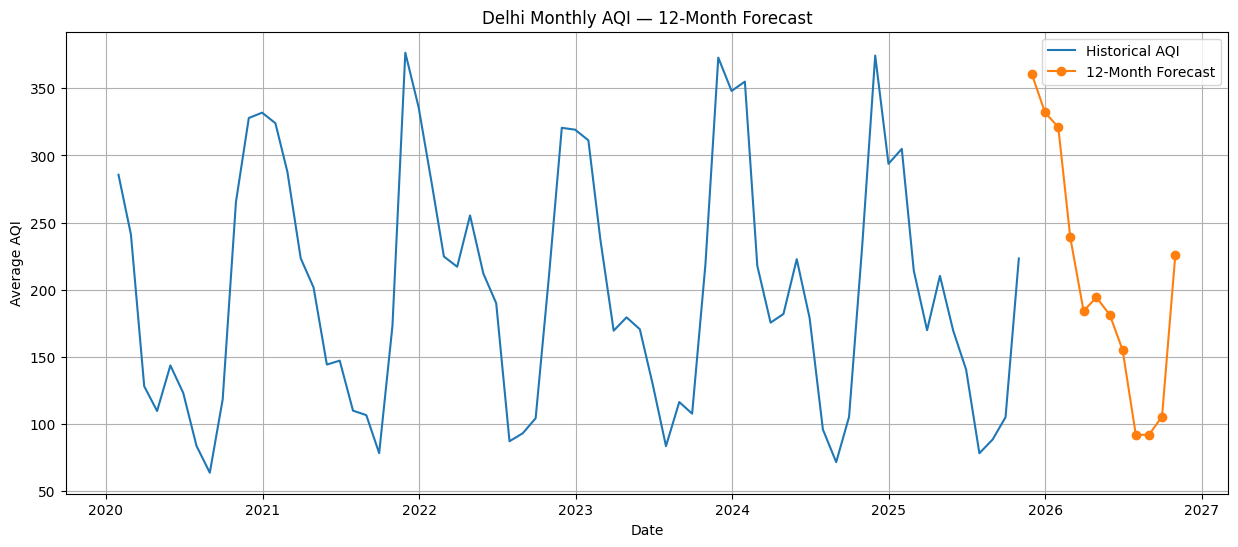

In [139]:
plt.figure(figsize=(15, 6))

plt.plot(
    delhi_monthly.index,
    delhi_monthly,
    label="Historical AQI"
)

plt.plot(
    future_forecast.index,
    future_forecast,
    marker="o",
    label="12-Month Forecast"
)

plt.title("Delhi Monthly AQI — 12-Month Forecast")
plt.xlabel("Date")
plt.ylabel("Average AQI")
plt.legend()
plt.grid(True)

plt.show()

Multi-City Forecasting

In [140]:
cities = [
    "Delhi",
    "Mumbai",
    "Kolkata",
    "Bengaluru",
    "Chennai"
]

print(cities)

['Delhi', 'Mumbai', 'Kolkata', 'Bengaluru', 'Chennai']


In [142]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd


def forecast_city(city):

    # -----------------------------
    # 1. Get city data
    # -----------------------------
    city_data = df[df["City"] == city].copy()

    city_data = city_data.sort_values("Date")

    # -----------------------------
    # 2. Create monthly AQI
    # -----------------------------
    monthly_aqi = (
        city_data
        .set_index("Date")["AQI Value"]
        .resample("ME")
        .mean()
    )

    # -----------------------------
    # 3. Train/Test split
    # Last 12 months = test
    # -----------------------------
    train = monthly_aqi.iloc[:-12]
    test = monthly_aqi.iloc[-12:]

    # -----------------------------
    # 4. Seasonal Naive
    # Previous year's same month
    # -----------------------------
    seasonal_naive = train.iloc[-12:].copy()
    seasonal_naive.index = test.index

    # -----------------------------
    # 5. Seasonal Naive metrics
    # -----------------------------
    naive_mae = mean_absolute_error(
        test,
        seasonal_naive
    )

    naive_rmse = np.sqrt(
        mean_squared_error(
            test,
            seasonal_naive
        )
    )

    naive_mape = np.mean(
        np.abs(
            (test - seasonal_naive) / test
        )
    ) * 100

    # -----------------------------
    # 6. SARIMA
    # -----------------------------
    model = SARIMAX(
        train,
        order=(1, 0, 1),
        seasonal_order=(1, 0, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    result = model.fit(disp=False)

    # -----------------------------
    # 7. SARIMA forecast
    # -----------------------------
    forecast = result.forecast(
        steps=len(test)
    )

    forecast.index = test.index

    # -----------------------------
    # 8. SARIMA metrics
    # -----------------------------
    sarima_mae = mean_absolute_error(
        test,
        forecast
    )

    sarima_rmse = np.sqrt(
        mean_squared_error(
            test,
            forecast
        )
    )

    sarima_mape = np.mean(
        np.abs(
            (test - forecast) / test
        )
    ) * 100

    # -----------------------------
    # 9. Final model
    # Train on ALL city data
    # -----------------------------
    final_model = SARIMAX(
        monthly_aqi,
        order=(1, 0, 1),
        seasonal_order=(1, 0, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    final_result = final_model.fit(disp=False)

    # -----------------------------
    # 10. Future 12-month forecast
    # -----------------------------
    future_forecast = final_result.forecast(
        steps=12
    )

    # -----------------------------
    # 11. Return everything
    # -----------------------------
    return {
        "city": city,
        "monthly_data": monthly_aqi,
        "train": train,
        "test": test,
        "seasonal_naive": seasonal_naive,
        "sarima_forecast": forecast,
        "naive_mae": naive_mae,
        "naive_rmse": naive_rmse,
        "naive_mape": naive_mape,
        "sarima_mae": sarima_mae,
        "sarima_rmse": sarima_rmse,
        "sarima_mape": sarima_mape,
        "future_forecast": future_forecast
    }

In [143]:
delhi_result = forecast_city("Delhi")

In [144]:
print("City:", delhi_result["city"])

print("\nSARIMA Test Performance")
print("-----------------------")
print("MAE :", round(delhi_result["sarima_mae"], 2))
print("RMSE:", round(delhi_result["sarima_rmse"], 2))
print("MAPE:", round(delhi_result["sarima_mape"], 2), "%")

City: Delhi

SARIMA Test Performance
-----------------------
MAE : 16.55
RMSE: 19.96
MAPE: 8.68 %


In [145]:
delhi_result["future_forecast"]

,predicted_mean
2025-11-30,360.964282
2025-12-31,332.060036
2026-01-31,321.079458
2026-02-28,239.052551
2026-03-31,184.331812
2026-04-30,194.340104
2026-05-31,181.496822
2026-06-30,155.268656
2026-07-31,91.912789
2026-08-31,92.233516


In [146]:
results = {}

for city in cities:
    print(f"Processing {city}...")
    results[city] = forecast_city(city)

print("Done.")

Processing Delhi...
Processing Mumbai...
Processing Kolkata...
Processing Bengaluru...
Processing Chennai...
Done.


In [147]:
model_comparison = []

for city, result in results.items():

    model_comparison.append({
        "City": city,

        "Naive MAE": result["naive_mae"],
        "Naive RMSE": result["naive_rmse"],
        "Naive MAPE": result["naive_mape"],

        "SARIMA MAE": result["sarima_mae"],
        "SARIMA RMSE": result["sarima_rmse"],
        "SARIMA MAPE": result["sarima_mape"]
    })

model_comparison = pd.DataFrame(model_comparison)

display(
    model_comparison.round(2)
)

,City,Naive MAE,Naive RMSE,Naive MAPE,SARIMA MAE,SARIMA RMSE,SARIMA MAPE
0,Delhi,23.38,30.72,13.26,16.55,19.96,8.68
1,Mumbai,10.03,11.81,11.80,13.88,18.54,13.86
2,Kolkata,13.95,20.91,13.77,11.94,14.33,15.44
3,Bengaluru,7.31,8.35,10.06,5.54,6.25,7.91
4,Chennai,8.35,10.38,11.57,8.18,10.71,10.78


In [148]:
model_comparison["MAE Improvement (%)"] = (
    (model_comparison["Naive MAE"] -
     model_comparison["SARIMA MAE"])
    / model_comparison["Naive MAE"]
) * 100

model_comparison["MAPE Improvement (%)"] = (
    (model_comparison["Naive MAPE"] -
     model_comparison["SARIMA MAPE"])
    / model_comparison["Naive MAPE"]
) * 100

display(
    model_comparison.round(2)
)

,City,Naive MAE,Naive RMSE,Naive MAPE,SARIMA MAE,SARIMA RMSE,SARIMA MAPE,MAE Improvement (%),MAPE Improvement (%)
0,Delhi,23.38,30.72,13.26,16.55,19.96,8.68,29.23,34.58
1,Mumbai,10.03,11.81,11.80,13.88,18.54,13.86,-38.33,-17.49
2,Kolkata,13.95,20.91,13.77,11.94,14.33,15.44,14.36,-12.17
3,Bengaluru,7.31,8.35,10.06,5.54,6.25,7.91,24.29,21.39
4,Chennai,8.35,10.38,11.57,8.18,10.71,10.78,2.05,6.81


SARIMA with a 12-month seasonal component improved forecasting performance for Delhi, Kolkata, Bengaluru and Chennai on the selected 12-month test periods, while the seasonal-naive baseline performed better for Mumbai. This indicates that forecasting performance varies by city and that model selection should be evaluated separately for each time series.

In [149]:
final_forecasts = {}

for city, result in results.items():

    monthly_data = result["monthly_data"]

    if city == "Mumbai":
        # Seasonal Naive: repeat previous 12 months
        future_forecast = monthly_data.iloc[-12:].copy()

        # Create next 12 monthly dates
        future_dates = pd.date_range(
            start=monthly_data.index[-1] + pd.offsets.MonthEnd(1),
            periods=12,
            freq="ME"
        )

        future_forecast.index = future_dates

    else:
        # Use SARIMA
        future_forecast = result["future_forecast"]

    final_forecasts[city] = future_forecast

In [150]:
final_forecast_table = []

for city, forecast in final_forecasts.items():

    for date, value in forecast.items():

        final_forecast_table.append({
            "City": city,
            "Date": date,
            "Forecasted_AQI": value
        })

final_forecast_table = pd.DataFrame(final_forecast_table)

display(
    final_forecast_table.round(2)
)

,City,Date,Forecasted_AQI
0,Delhi,2025-11-30,360.96
1,Delhi,2025-12-31,332.06
2,Delhi,2026-01-31,321.08
3,Delhi,2026-02-28,239.05
4,Delhi,2026-03-31,184.33
5,Delhi,2026-04-30,194.34
6,Delhi,2026-05-31,181.50
7,Delhi,2026-06-30,155.27
8,Delhi,2026-07-31,91.91
9,Delhi,2026-08-31,92.23


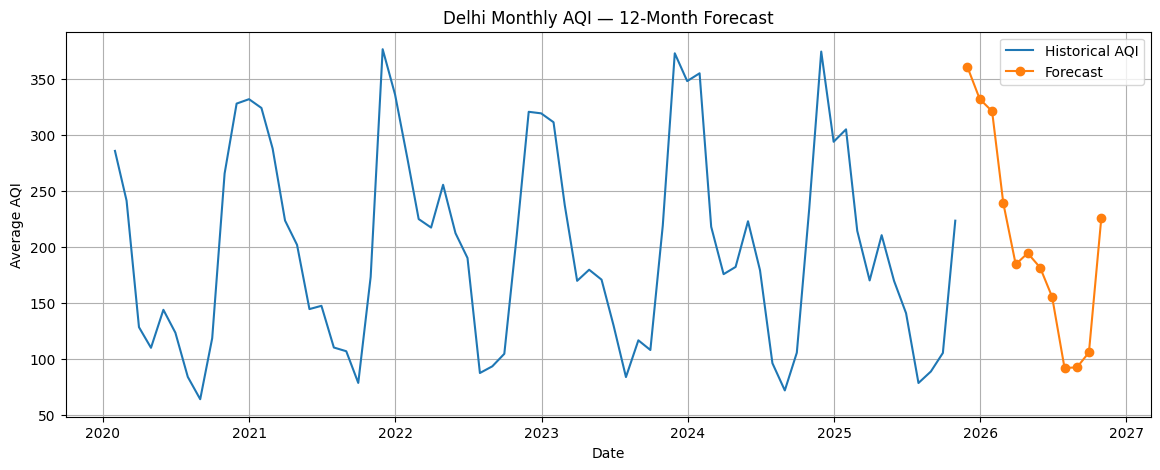

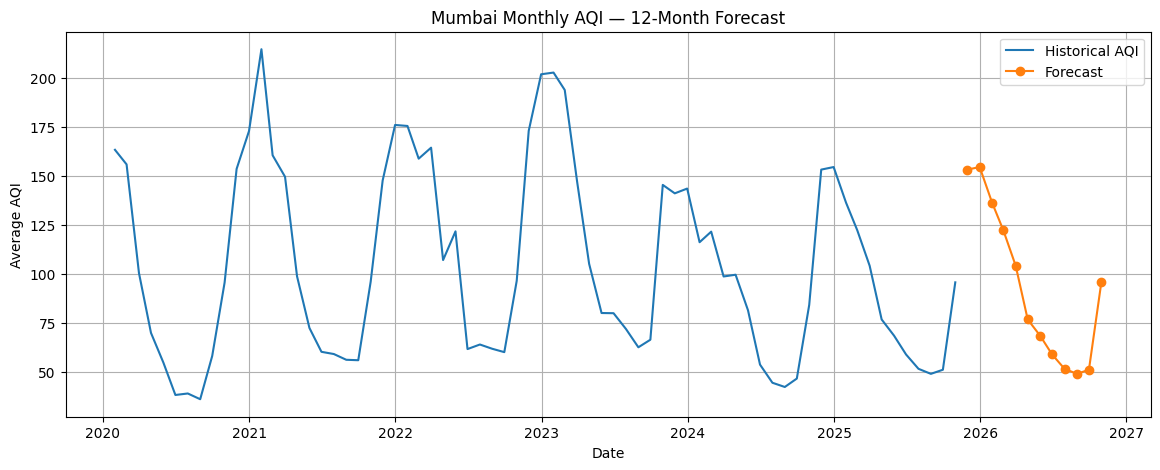

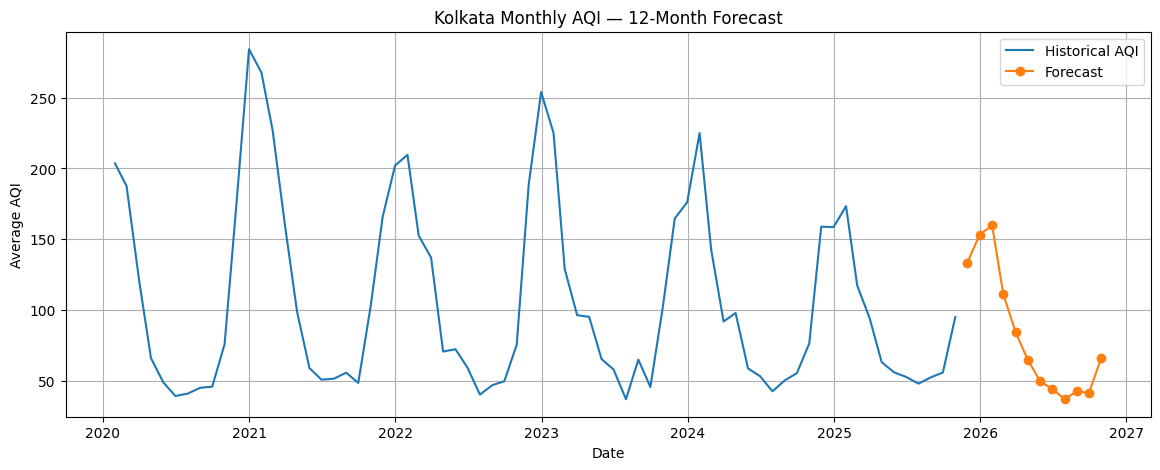

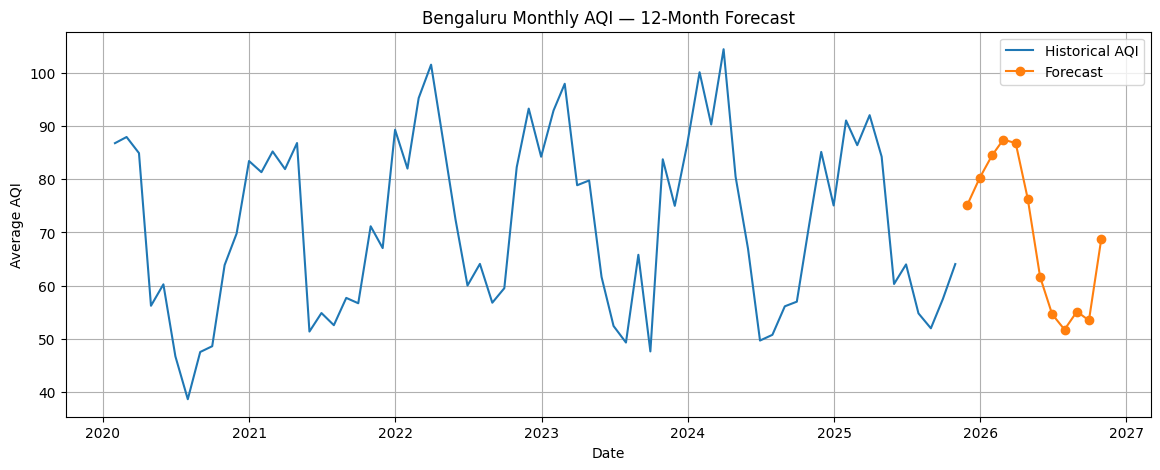

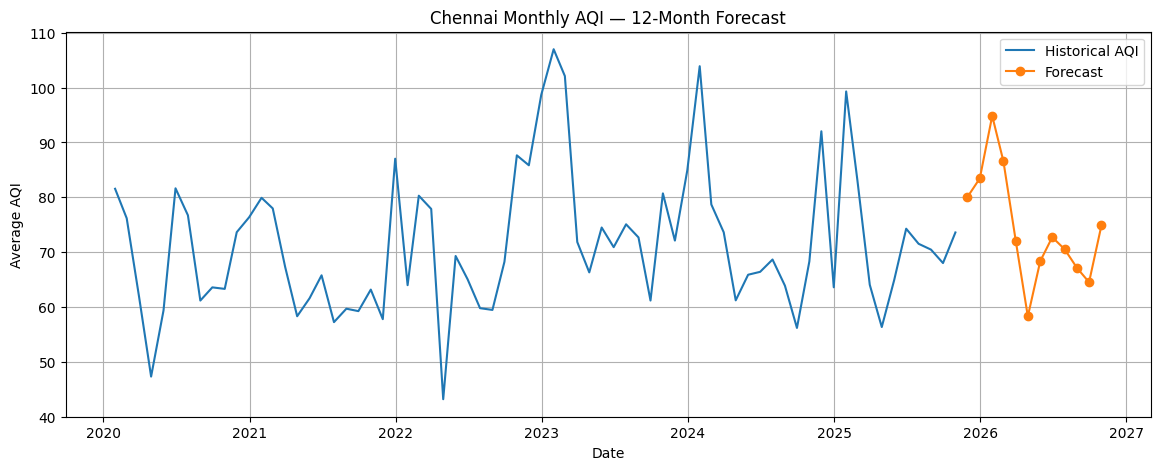

In [151]:
for city in cities:

    historical = results[city]["monthly_data"]
    forecast = final_forecasts[city]

    plt.figure(figsize=(14, 5))

    plt.plot(
        historical.index,
        historical.values,
        label="Historical AQI"
    )

    plt.plot(
        forecast.index,
        forecast.values,
        marker="o",
        label="Forecast"
    )

    plt.title(f"{city} Monthly AQI — 12-Month Forecast")
    plt.xlabel("Date")
    plt.ylabel("Average AQI")
    plt.legend()
    plt.grid(True)

    plt.show()

In [152]:
forecast_summary = (
    final_forecast_table
    .groupby("City")["Forecasted_AQI"]
    .mean()
    .sort_values(ascending=False)
)

display(
    forecast_summary.round(2)
)

,Forecasted_AQI
City,
Delhi,207.03
Mumbai,93.55
Kolkata,82.41
Chennai,74.43
Bengaluru,69.67


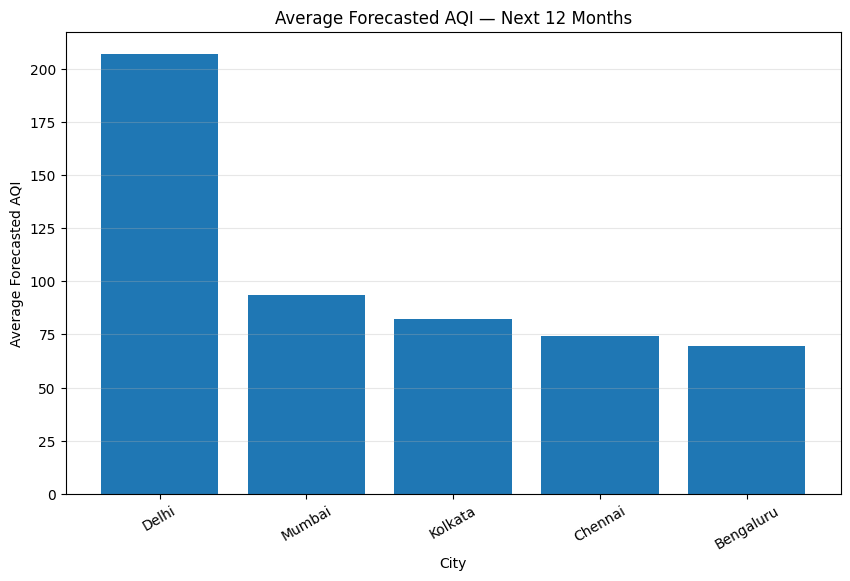

In [153]:
plt.figure(figsize=(10, 6))

plt.bar(
    forecast_summary.index,
    forecast_summary.values
)

plt.title("Average Forecasted AQI — Next 12 Months")
plt.xlabel("City")
plt.ylabel("Average Forecasted AQI")

plt.xticks(rotation=30)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

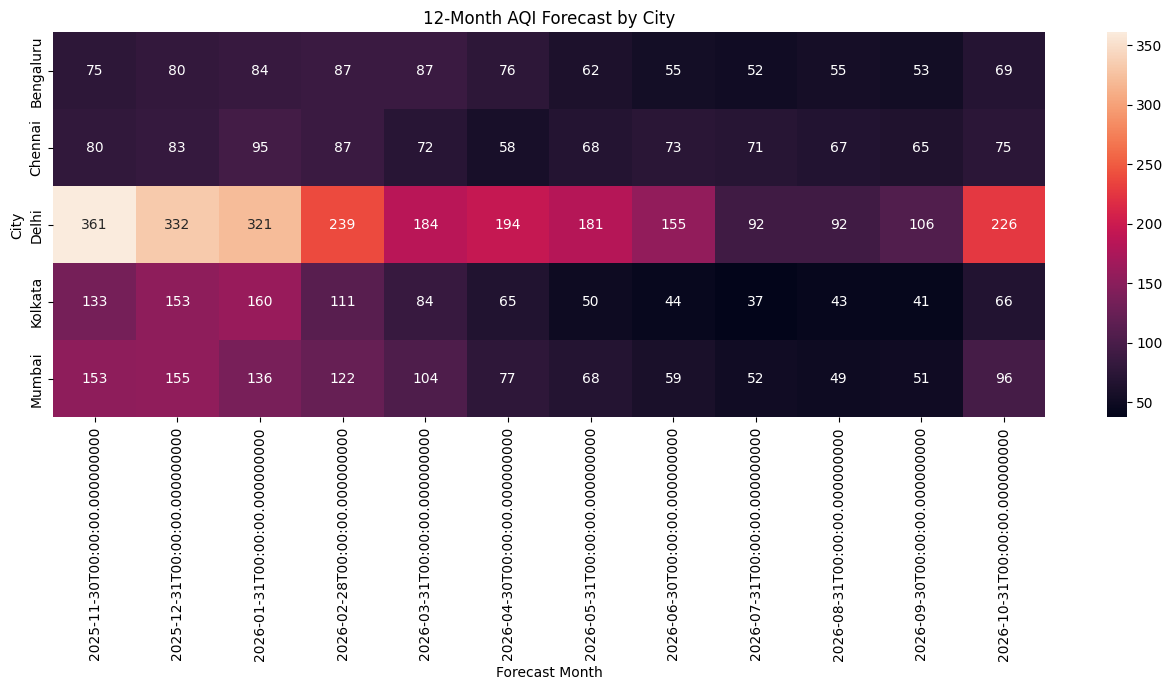

In [154]:
forecast_pivot = final_forecast_table.pivot(
    index="City",
    columns="Date",
    values="Forecasted_AQI"
)

plt.figure(figsize=(16, 5))

sns.heatmap(
    forecast_pivot,
    annot=True,
    fmt=".0f"
)

plt.title("12-Month AQI Forecast by City")
plt.xlabel("Forecast Month")
plt.ylabel("City")

plt.show()

In [155]:
forecast_insights = []

for city, forecast in final_forecasts.items():

    max_date = forecast.idxmax()
    min_date = forecast.idxmin()

    max_aqi = forecast.max()
    min_aqi = forecast.min()

    forecast_insights.append({
        "City": city,
        "Peak Forecast Month": max_date.strftime("%Y-%m"),
        "Peak Forecast AQI": round(max_aqi, 2),
        "Lowest Forecast Month": min_date.strftime("%Y-%m"),
        "Lowest Forecast AQI": round(min_aqi, 2)
    })

forecast_insights = pd.DataFrame(forecast_insights)

display(forecast_insights)

,City,Peak Forecast Month,Peak Forecast AQI,Lowest Forecast Month,Lowest Forecast AQI
0,Delhi,2025-11,360.96,2026-07,91.91
1,Mumbai,2025-12,154.68,2026-08,48.97
2,Kolkata,2026-01,159.88,2026-07,37.20
3,Bengaluru,2026-02,87.44,2026-07,51.76
4,Chennai,2026-01,94.84,2026-04,58.26


In [156]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

In [157]:
prophet_df = delhi_monthly.reset_index()

prophet_df.columns = ["ds", "y"]

In [158]:
train = prophet_df.iloc[:-12]
test = prophet_df.iloc[-12:]

In [159]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(train)

In [160]:
future = model.make_future_dataframe(periods=12, freq="ME")

forecast = model.predict(future)

In [161]:
pred = forecast.set_index("ds").loc[test["ds"], "yhat"]
actual = test.set_index("ds")["y"]

In [162]:
mae = mean_absolute_error(actual, pred)

rmse = np.sqrt(
    mean_squared_error(actual, pred)
)

mape = np.mean(
    np.abs((actual - pred) / actual)
) * 100

print("Prophet MAE :", round(mae, 2))
print("Prophet RMSE:", round(rmse, 2))
print("Prophet MAPE:", round(mape, 2))

Prophet MAE : 24.74
Prophet RMSE: 27.57
Prophet MAPE: 14.65


In [163]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

def evaluate_prophet(city):

    # Monthly AQI
    city_monthly = (
        df[df["City"] == city]
        .set_index("Date")["AQI Value"]
        .resample("ME")
        .mean()
    )

    # Prophet format
    prophet_df = city_monthly.reset_index()
    prophet_df.columns = ["ds", "y"]

    # Last 12 months = test
    train = prophet_df.iloc[:-12].copy()
    test = prophet_df.iloc[-12:].copy()

    # Prophet model
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False
    )

    model.fit(train)

    # Forecast
    future = model.make_future_dataframe(
        periods=12,
        freq="ME"
    )

    forecast = model.predict(future)

    # Test predictions
    predictions = (
        forecast.set_index("ds")
        .loc[test["ds"], "yhat"]
    )

    actual = test.set_index("ds")["y"]

    # Metrics
    mae = mean_absolute_error(actual, predictions)

    rmse = np.sqrt(
        mean_squared_error(actual, predictions)
    )

    mape = np.mean(
        np.abs((actual - predictions) / actual)
    ) * 100

    return {
        "City": city,
        "Prophet MAE": mae,
        "Prophet RMSE": rmse,
        "Prophet MAPE": mape
    }

In [164]:
cities = [
    "Delhi",
    "Mumbai",
    "Kolkata",
    "Bengaluru",
    "Chennai"
]

prophet_results = []

for city in cities:
    print(f"Running Prophet for {city}...")

    result = evaluate_prophet(city)
    prophet_results.append(result)

prophet_comparison = pd.DataFrame(prophet_results)

prophet_comparison = prophet_comparison.round(2)

display(prophet_comparison)

Running Prophet for Delhi...
Running Prophet for Mumbai...
Running Prophet for Kolkata...
Running Prophet for Bengaluru...
Running Prophet for Chennai...


,City,Prophet MAE,Prophet RMSE,Prophet MAPE
0,Delhi,24.74,27.57,14.65
1,Mumbai,15.22,23.10,14.68
2,Kolkata,22.90,32.04,22.34
3,Bengaluru,6.62,7.91,9.36
4,Chennai,8.15,11.81,11.71


Forecasting performance varies across cities, so model selection should be based on validation performance rather than assuming one forecasting method is universally optimal.

In [165]:
final_model_comparison = pd.DataFrame([
    {
        "City": "Delhi",
        "Final Model": "SARIMA",
        "Reason": "Best overall validation performance"
    },
    {
        "City": "Mumbai",
        "Final Model": "Seasonal Naive",
        "Reason": "Best validation performance"
    },
    {
        "City": "Kolkata",
        "Final Model": "SARIMA",
        "Reason": "Better validation performance than baselines"
    },
    {
        "City": "Bengaluru",
        "Final Model": "SARIMA",
        "Reason": "Best overall validation performance"
    },
    {
        "City": "Chennai",
        "Final Model": "SARIMA",
        "Reason": "Lower RMSE and MAPE; Prophet only slightly lower MAE"
    }
])

display(final_model_comparison)


,City,Final Model,Reason
0,Delhi,SARIMA,Best overall validation performance
1,Mumbai,Seasonal Naive,Best validation performance
2,Kolkata,SARIMA,Better validation performance than baselines
3,Bengaluru,SARIMA,Best overall validation performance
4,Chennai,SARIMA,Lower RMSE and MAPE; Prophet only slightly low...


In [166]:
final_comparison = model_comparison.merge(
    prophet_comparison,
    on="City"
)

display(final_comparison.round(2))

,City,Naive MAE,Naive RMSE,Naive MAPE,SARIMA MAE,SARIMA RMSE,SARIMA MAPE,MAE Improvement (%),MAPE Improvement (%),Prophet MAE,Prophet RMSE,Prophet MAPE
0,Delhi,23.38,30.72,13.26,16.55,19.96,8.68,29.23,34.58,24.74,27.57,14.65
1,Mumbai,10.03,11.81,11.80,13.88,18.54,13.86,-38.33,-17.49,15.22,23.10,14.68
2,Kolkata,13.95,20.91,13.77,11.94,14.33,15.44,14.36,-12.17,22.90,32.04,22.34
3,Bengaluru,7.31,8.35,10.06,5.54,6.25,7.91,24.29,21.39,6.62,7.91,9.36
4,Chennai,8.35,10.38,11.57,8.18,10.71,10.78,2.05,6.81,8.15,11.81,11.71


In [167]:
forecast_summary = (
    final_forecast_table
    .groupby("City")["Forecasted_AQI"]
    .agg(
        Average_Forecast_AQI="mean",
        Maximum_Forecast_AQI="max",
        Minimum_Forecast_AQI="min"
    )
    .round(2)
)

display(forecast_summary)

,Average_Forecast_AQI,Maximum_Forecast_AQI,Minimum_Forecast_AQI
City,,,
Bengaluru,69.67,87.44,51.76
Chennai,74.43,94.84,58.26
Delhi,207.03,360.96,91.91
Kolkata,82.41,159.88,37.20
Mumbai,93.55,154.68,48.97


In [168]:
forecast_insights = []

for city, forecast in final_forecasts.items():

    forecast_insights.append({
        "City": city,
        "Peak Month": forecast.idxmax().strftime("%Y-%m"),
        "Peak AQI": round(forecast.max(), 2),
        "Lowest Month": forecast.idxmin().strftime("%Y-%m"),
        "Lowest AQI": round(forecast.min(), 2)
    })

forecast_insights = pd.DataFrame(forecast_insights)

display(forecast_insights)

,City,Peak Month,Peak AQI,Lowest Month,Lowest AQI
0,Delhi,2025-11,360.96,2026-07,91.91
1,Mumbai,2025-12,154.68,2026-08,48.97
2,Kolkata,2026-01,159.88,2026-07,37.20
3,Bengaluru,2026-02,87.44,2026-07,51.76
4,Chennai,2026-01,94.84,2026-04,58.26


## 12-Month Forecast Findings

Using the final selected models, monthly AQI was forecast for the
12-month period following the dataset's last observed month (October 2025).

The forecast shows clear differences in the expected AQI range across
the five selected cities.

- Delhi has the highest average forecast AQI (207.03) and reaches a
  forecast maximum of 360.96 in November 2025.
- Mumbai has an average forecast AQI of 93.55, with a forecast maximum
  of 154.68 in December 2025.
- Kolkata has an average forecast AQI of 82.41 and reaches a maximum
  forecast of 159.88 in January 2026.
- Bengaluru has the lowest average forecast AQI among the five cities
  at 69.67, with a forecast range from 51.76 to 87.44.
- Chennai has an average forecast AQI of 74.43, with a maximum forecast
  of 94.84 in January 2026.

The forecasts generally show higher AQI values during late-year and
winter months and lower values during several middle-year months.
This pattern is consistent with the annual seasonality identified
during the historical time-series analysis.

These forecasts represent statistical model estimates based on
historical AQI patterns and should not be interpreted as guaranteed
future observations.

## Final Forecasting Findings

The forecasting analysis compared three approaches: Seasonal Naive,
SARIMA, and Prophet, using the final 12 months of each city's monthly
AQI data as the test period.

The results show that forecasting performance varies across cities.

- Delhi: SARIMA achieved lower MAE, RMSE, and MAPE than the Seasonal Naive
  and Prophet models.
- Mumbai: Seasonal Naive produced lower errors than SARIMA and Prophet.
- Kolkata: SARIMA achieved lower MAE and RMSE than the Seasonal Naive
  baseline, although its MAPE was slightly higher.
- Bengaluru: SARIMA achieved the lowest MAE, RMSE, and MAPE among the
  evaluated models.
- Chennai: Prophet achieved a marginally lower MAE than SARIMA, while
  SARIMA achieved lower RMSE and MAPE.

Therefore, the final forecasting model was selected separately for each
city based on validation performance rather than assuming that one model
would perform best for all cities.

The selected models were:
Delhi – SARIMA
Mumbai – Seasonal Naive
Kolkata – SARIMA
Bengaluru – SARIMA
Chennai – SARIMA

## Limitations

1. The analysis is based on historical AQI observations and does not
   establish causal relationships between individual pollutants and AQI.

2. The dataset contains a Prominent Pollutant column with the same
   categorical value across all observations, so it does not provide
   useful variation for pollutant-level analysis.

3. The final forecasting evaluation uses the last 12 months as a
   holdout test period. Performance may vary for different forecasting
   horizons or future periods.

4. Model performance varies across cities, meaning that a single
   forecasting model may not be optimal for every location.

5. The 2025 data ends in October, so the later forecast period should
   be interpreted as model-generated estimates based on the available
   historical data.

6. The forecasts capture historical statistical patterns and
   seasonality but do not account for unexpected events, policy changes,
   weather conditions, or other external factors.

7. The analysis focuses on AQI values and does not contain continuous
   pollutant concentration measurements such as PM2.5 or PM10 values.

## Conclusion

This project analyzed historical Air Quality Index (AQI) data across
Indian cities and developed a time-series forecasting pipeline for
selected major cities.

The exploratory analysis revealed a strong seasonal pattern in AQI,
with higher values generally occurring during late-year and winter
months and lower values during several middle-year months.

Several forecasting approaches were evaluated, including Seasonal
Naive, ARIMA, SARIMA, and Prophet. The results demonstrated that
forecasting performance varies across cities. SARIMA performed strongly
for Delhi, Kolkata, and Bengaluru, while the Seasonal Naive approach
performed better for Mumbai. For Chennai, SARIMA achieved lower RMSE and
MAPE than Prophet, although Prophet produced a marginally lower MAE.

Based on the selected validation results, city-specific models were
used to generate 12-month AQI forecasts. The forecasts reproduced the
broad seasonal pattern observed in the historical data.

Overall, the project demonstrates a complete Python-based workflow for
AQI analysis and time-series forecasting, from data preparation and
exploratory analysis to model evaluation, selection, and future
forecast generation.

The forecasts should be interpreted as statistical estimates based on
historical patterns rather than guaranteed future AQI values.